In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.optimize import minimize

In [12]:
mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

In [ ]:
import pandas as pd
import numpy as np

import os

BASE_DIR = r"C:\Users\a0109\OneDrive\바탕 화면\다트_모의투자_수정"
os.chdir(BASE_DIR)

print("작업 폴더:", os.getcwd())

# ============================================================
# 0. 기본 설정
# ============================================================

PRICE_FILE = "종가.xlsx"
VALUE_FILE = "거래대금.xlsx"
MCAP_FILE = "시가총액.xlsx"
LISTING_FILE = "상장일.xlsx"
INFO_FILE = "종목기본정보.xlsx"

MIN_MARKET_CAP = 100_000_000_000     # 1,000억원
MIN_AVG_VALUE = 3_000_000_000        # 30억원
VALUE_WINDOW = 5                      # 최근 5거래일 평균 거래대금


# ============================================================
# 1. 데이터 불러오기
# ============================================================

price = pd.read_excel(PRICE_FILE)
value = pd.read_excel(VALUE_FILE)
mcap = pd.read_excel(MCAP_FILE)

listing = pd.read_excel(LISTING_FILE)
info = pd.read_excel(INFO_FILE)

print("종가:", price.shape)
print("거래대금:", value.shape)
print("시가총액:", mcap.shape)
print("상장일:", listing.shape)
print("종목기본정보:", info.shape)


# ============================================================
# 2. 날짜 열 정리
# ============================================================

def clean_date_index(df, name):

    df = df.copy()

    # 첫 번째 열을 날짜로 변환 시도
    # 날짜가 아닌 '달력기준', 설명문구 등은 NaT 처리
    parsed_date = pd.to_datetime(
        df.iloc[:, 0],
        errors="coerce"
    )

    # 실제 날짜로 변환된 행만 남기기
    valid_rows = parsed_date.notna()

    df = df.loc[valid_rows].copy()

    # 변환된 날짜를 첫 번째 열에 다시 넣기
    df.iloc[:, 0] = parsed_date.loc[valid_rows]

    # 첫 번째 열을 날짜 index로 설정
    df = df.set_index(df.columns[0])

    # 날짜순 정렬
    df = df.sort_index()

    print(
        f"{name}:",
        df.shape,
        "/ 기간:",
        df.index.min(),
        "~",
        df.index.max()
    )

    return df


price = clean_date_index(price, "종가")
value = clean_date_index(value, "거래대금")
mcap = clean_date_index(mcap, "시가총액")


# ============================================================
# 3. 종목코드 형식 통일
# ============================================================

def clean_code(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    # 엑셀에서 5930.0처럼 들어온 경우
    if x.endswith(".0"):
        x = x[:-2]

    # 숫자형 종목코드 → 6자리 맞춤
    if x.isdigit():
        x = x.zfill(6)

    return x


price.columns = [clean_code(c) for c in price.columns]
value.columns = [clean_code(c) for c in value.columns]
mcap.columns = [clean_code(c) for c in mcap.columns]


# ============================================================
# 4. 세 데이터 공통 종목만 사용
# ============================================================

common_codes = sorted(
    set(price.columns)
    & set(value.columns)
    & set(mcap.columns)
)

price = price[common_codes]
value = value[common_codes]
mcap = mcap[common_codes]

print("\n공통 종목 수:", len(common_codes))


# ============================================================
# 5. 공통 거래일 맞추기
# ============================================================

common_dates = (
    price.index
    .intersection(value.index)
    .intersection(mcap.index)
)

price = price.loc[common_dates]
value = value.loc[common_dates]
mcap = mcap.loc[common_dates]

print("공통 거래일:", len(common_dates))
print("기간:", common_dates.min(), "~", common_dates.max())


# ============================================================
# 6. 거래대금 5일 평균 계산
# ============================================================

avg_value_5d = value.rolling(
    window=VALUE_WINDOW,
    min_periods=VALUE_WINDOW
).mean()




종가: (2341, 6281)
거래대금: (2341, 6281)
시가총액: (2341, 6281)
상장일: (6285, 3)
종목기본정보: (6285, 6)


C:\Users\a0109\AppData\Local\Temp\ipykernel_17808\2992545849.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_date = pd.to_datetime(


종가: (2328, 6280) / 기간: 2017-03-28 00:00:00 ~ 2026-09-28 00:00:00


C:\Users\a0109\AppData\Local\Temp\ipykernel_17808\2992545849.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_date = pd.to_datetime(


거래대금: (2328, 6280) / 기간: 2017-03-28 00:00:00 ~ 2026-09-28 00:00:00


C:\Users\a0109\AppData\Local\Temp\ipykernel_17808\2992545849.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_date = pd.to_datetime(


시가총액: (2328, 6280) / 기간: 2017-03-28 00:00:00 ~ 2026-09-28 00:00:00

공통 종목 수: 6279
공통 거래일: 2328
기간: 2017-03-28 00:00:00 ~ 2026-09-28 00:00:00

상장일 파일 컬럼:
['Refresh', 'Last Updated: 2026-09-29 13:17:56', 'Unnamed: 2']


ValueError: 상장일.xlsx에서 종목코드 열을 찾지 못했습니다.

In [32]:
import pandas as pd

listing = pd.read_excel("상장일.xlsx", header=5)
print(listing.head())

        코드         코드명         상장일
0  A000010     (주)신한은행  19560303.0
1  A000011    조흥은행(1신)  19750805.0
2  A000012    조흥은행(2신)  19890725.0
3  A000020        동화약품  19760324.0
4  A000021  동화약품공업(1신)  19760324.0


In [33]:
listing["코드"] = listing["코드"].astype(str).str.replace("A", "", regex=False).str.zfill(6)

listing["상장일"] = pd.to_datetime(
    listing["상장일"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

print(listing.head())
print(listing.dtypes)

       코드         코드명 상장일
0  000010     (주)신한은행 NaT
1  000011    조흥은행(1신) NaT
2  000012    조흥은행(2신) NaT
3  000020        동화약품 NaT
4  000021  동화약품공업(1신) NaT
코드               str
코드명              str
상장일    datetime64[s]
dtype: object


In [35]:
# 상장일.xlsx만 다시 읽기
listing = pd.read_excel("상장일.xlsx", header=5)

# 종목코드 정리
listing["코드"] = (
    listing["코드"]
    .astype(str)
    .str.replace("A", "", regex=False)
    .str.zfill(6)
)

# 19560303.0 → 19560303 형태로 만든 뒤 날짜 변환
listing["상장일"] = pd.to_numeric(
    listing["상장일"],
    errors="coerce"
)

listing["상장일"] = pd.to_datetime(
    listing["상장일"].astype("Int64").astype(str),
    format="%Y%m%d",
    errors="coerce"
)

print(listing.head())
print(listing.dtypes)
print("상장일 결측치:", listing["상장일"].isna().sum())

       코드         코드명        상장일
0  000010     (주)신한은행 1956-03-03
1  000011    조흥은행(1신) 1975-08-05
2  000012    조흥은행(2신) 1989-07-25
3  000020        동화약품 1976-03-24
4  000021  동화약품공업(1신) 1976-03-24
코드                str
코드명               str
상장일    datetime64[us]
dtype: object
상장일 결측치: 334


In [36]:
info_test = pd.read_excel("종목기본정보.xlsx", header=None)

print(info_test.head(15))

            0                                  1           2           3  \
0     Refresh  Last Updated: 2026-09-29 13:24:27         NaN         NaN   
1        특정시점                                NaN         COM         COM   
2    코드 포트폴리오          [코스피+코스닥[상장폐지 포함](I.00P)]                           
3   아이템 포트폴리오                                NaN     Current     Current   
4          통화                                 원화  CP10001500  CP10001600   
5          코드                                코드명       최초상장일       상장폐지일   
6     A000010                            (주)신한은행    19560303    20040702   
7     A000011                           조흥은행(1신)    19750805         NaN   
8     A000012                           조흥은행(2신)    19890725         NaN   
9     A000020                               동화약품    19760324         NaN   
10    A000021                         동화약품공업(1신)    19760324         NaN   
11    A000030                            (주)우리은행    19560303    20190213   
12    A00003

In [37]:
info = pd.read_excel("종목기본정보.xlsx", header=5)

print(info.head())
print(info.columns.tolist())

        코드         코드명       최초상장일       상장폐지일  시장이전일  시장이전내용
0  A000010     (주)신한은행  19560303.0  20040702.0    NaN     NaN
1  A000011    조흥은행(1신)  19750805.0         NaN    NaN     NaN
2  A000012    조흥은행(2신)  19890725.0         NaN    NaN     NaN
3  A000020        동화약품  19760324.0         NaN    NaN     NaN
4  A000021  동화약품공업(1신)  19760324.0         NaN    NaN     NaN
['코드', '코드명', '최초상장일', '상장폐지일', '시장이전일', '시장이전내용']


In [38]:
# 종목코드 정리
info["코드"] = (
    info["코드"]
    .astype(str)
    .str.replace("A", "", regex=False)
    .str.zfill(6)
)

# 날짜형으로 변환할 컬럼
date_cols = ["최초상장일", "상장폐지일", "시장이전일"]

for col in date_cols:
    if col in info.columns:
        info[col] = pd.to_numeric(info[col], errors="coerce")
        info[col] = pd.to_datetime(
            info[col].astype("Int64").astype(str),
            format="%Y%m%d",
            errors="coerce"
        )

print(info.head())
print(info.dtypes)

       코드         코드명      최초상장일      상장폐지일 시장이전일  시장이전내용
0  000010     (주)신한은행 1956-03-03 2004-07-02   NaT     NaN
1  000011    조흥은행(1신) 1975-08-05        NaT   NaT     NaN
2  000012    조흥은행(2신) 1989-07-25        NaT   NaT     NaN
3  000020        동화약품 1976-03-24        NaT   NaT     NaN
4  000021  동화약품공업(1신) 1976-03-24        NaT   NaT     NaN
코드                   str
코드명                  str
최초상장일     datetime64[us]
상장폐지일     datetime64[us]
시장이전일      datetime64[s]
시장이전내용           float64
dtype: object


In [39]:
print(price.columns[:10])
print(value.columns[:10])
print(mcap.columns[:10])

Index(['Unnamed: 10', 'Unnamed: 100', 'Unnamed: 1000', 'Unnamed: 1001',
       'Unnamed: 1002', 'Unnamed: 1003', 'Unnamed: 1004', 'Unnamed: 1005',
       'Unnamed: 1006', 'Unnamed: 1007'],
      dtype='str')
Index(['Unnamed: 10', 'Unnamed: 100', 'Unnamed: 1000', 'Unnamed: 1001',
       'Unnamed: 1002', 'Unnamed: 1003', 'Unnamed: 1004', 'Unnamed: 1005',
       'Unnamed: 1006', 'Unnamed: 1007'],
      dtype='str')
Index(['Unnamed: 10', 'Unnamed: 100', 'Unnamed: 1000', 'Unnamed: 1001',
       'Unnamed: 1002', 'Unnamed: 1003', 'Unnamed: 1004', 'Unnamed: 1005',
       'Unnamed: 1006', 'Unnamed: 1007'],
      dtype='str')


In [40]:
price_test = pd.read_excel("종가.xlsx", header=None)

print(price_test.head(12))

         0                                  1               2           3     \
0     Refresh  Last Updated: 2026-09-29 12:28:44             NaN         NaN   
1        달력기준                                NaN             NaN         NaN   
2    코드 포트폴리오          [코스피+코스닥[상장폐지 포함](I.00P)]            기본설정         NaN   
3   아이템 포트폴리오                                NaN             NaN         NaN   
4        출력주기                                 일간              원화         NaN   
5        비영업일                                 제외            오름차순         NaN   
6        주말포함                                 제외             NaN         NaN   
7          기간                           20170328  최근일자(20260928)         NaN   
8          코드                            A000010         A000011     A000012   
9         코드명                            (주)신한은행        조흥은행(1신)    조흥은행(2신)   
10         유형                                SSC             SSC         SSC   
11      아이템코드                         S4

In [41]:
print(price_test.iloc[7:20, :8])

                      0           1               2           3           4  \
7                    기간    20170328  최근일자(20260928)         NaN         NaN   
8                    코드     A000010         A000011     A000012     A000020   
9                   코드명     (주)신한은행        조흥은행(1신)    조흥은행(2신)        동화약품   
10                   유형         SSC             SSC         SSC         SSC   
11                아이템코드  S41000060F      S41000060F  S41000060F  S41000060F   
12                 아이템명       종가(원)           종가(원)       종가(원)       종가(원)   
13                 집계주기          일간              일간          일간          일간   
14  2017-03-28 00:00:00         NaN             NaN         NaN        9130   
15  2017-03-29 00:00:00         NaN             NaN         NaN        9170   
16  2017-03-30 00:00:00         NaN             NaN         NaN        9160   
17  2017-03-31 00:00:00         NaN             NaN         NaN        9090   
18  2017-04-03 00:00:00         NaN             NaN 

In [42]:
# ============================================================
# 종가 데이터 실제 부분만 추출
# ============================================================

# 14행부터 실제 가격 데이터 / 1열부터 종목 데이터
price = price_test.iloc[14:, 1:].copy()

# 8행에 있는 종목코드를 컬럼명으로 사용
price.columns = (
    price_test.iloc[8, 1:]
    .astype(str)
    .str.replace("A", "", regex=False)
    .str.zfill(6)
)

# 0열에 있는 날짜를 index로 사용
price.index = pd.to_datetime(
    price_test.iloc[14:, 0],
    errors="coerce"
)

# 날짜 변환 실패한 행 제거
price = price.loc[price.index.notna()]

# 가격을 숫자로 변환
price = price.apply(pd.to_numeric, errors="coerce")

# 날짜순 정렬
price = price.sort_index()

print("종가 shape:", price.shape)
print("기간:", price.index.min(), "~", price.index.max())
print("앞쪽 종목코드:", price.columns[:10].tolist())
print(price.iloc[:5, :5])

종가 shape: (2328, 6280)
기간: 2017-03-28 00:00:00 ~ 2026-09-28 00:00:00
앞쪽 종목코드: ['000010', '000011', '000012', '000020', '000021', '000030', '000031', '000032', '000040', '000041']
8           000010  000011  000012  000020  000021
0                                                 
2017-03-28     NaN     NaN     NaN    9130     NaN
2017-03-29     NaN     NaN     NaN    9170     NaN
2017-03-30     NaN     NaN     NaN    9160     NaN
2017-03-31     NaN     NaN     NaN    9090     NaN
2017-04-03     NaN     NaN     NaN    9370     NaN


In [43]:
value_test = pd.read_excel("거래대금.xlsx", header=None)

print(value_test.iloc[7:20, :8])

                      0           1               2           3           4  \
7                    기간    20170328  최근일자(20260928)         NaN         NaN   
8                    코드     A000010         A000011     A000012     A000020   
9                   코드명     (주)신한은행        조흥은행(1신)    조흥은행(2신)        동화약품   
10                   유형         SSC             SSC         SSC         SSC   
11                아이템코드  S410000900      S410000900  S410000900  S410000900   
12                 아이템명     거래대금(원)         거래대금(원)     거래대금(원)     거래대금(원)   
13                 집계주기          일간              일간          일간          일간   
14  2017-03-28 00:00:00         NaN             NaN         NaN  1585906840   
15  2017-03-29 00:00:00         NaN             NaN         NaN   992426090   
16  2017-03-30 00:00:00         NaN             NaN         NaN   689128690   
17  2017-03-31 00:00:00         NaN             NaN         NaN  4123146700   
18  2017-04-03 00:00:00         NaN             NaN 

In [44]:
# ============================================================
# 거래대금 데이터 정리
# ============================================================

value = value_test.iloc[14:, 1:].copy()

value.columns = (
    value_test.iloc[8, 1:]
    .astype(str)
    .str.replace("A", "", regex=False)
    .str.zfill(6)
)

value.index = pd.to_datetime(
    value_test.iloc[14:, 0],
    errors="coerce"
)

value = value.loc[value.index.notna()]

value = value.apply(pd.to_numeric, errors="coerce")

value = value.sort_index()

print("거래대금 shape:", value.shape)
print("기간:", value.index.min(), "~", value.index.max())
print("앞쪽 종목코드:", value.columns[:10].tolist())
print(value.iloc[:5, :5])

거래대금 shape: (2328, 6280)
기간: 2017-03-28 00:00:00 ~ 2026-09-28 00:00:00
앞쪽 종목코드: ['000010', '000011', '000012', '000020', '000021', '000030', '000031', '000032', '000040', '000041']
8           000010  000011  000012      000020  000021
0                                                     
2017-03-28     NaN     NaN     NaN  1585906840     NaN
2017-03-29     NaN     NaN     NaN   992426090     NaN
2017-03-30     NaN     NaN     NaN   689128690     NaN
2017-03-31     NaN     NaN     NaN  4123146700     NaN
2017-04-03     NaN     NaN     NaN  1711832960     NaN


In [45]:
mcap_test = pd.read_excel("시가총액.xlsx", header=None)

mcap = mcap_test.iloc[14:, 1:].copy()

mcap.columns = (
    mcap_test.iloc[8, 1:]
    .astype(str)
    .str.replace("A", "", regex=False)
    .str.zfill(6)
)

mcap.index = pd.to_datetime(
    mcap_test.iloc[14:, 0],
    errors="coerce"
)

mcap = mcap.loc[mcap.index.notna()]

mcap = mcap.apply(pd.to_numeric, errors="coerce")

mcap = mcap.sort_index()

print("시가총액 shape:", mcap.shape)
print("기간:", mcap.index.min(), "~", mcap.index.max())
print("앞쪽 종목코드:", mcap.columns[:10].tolist())
print(mcap.iloc[:5, :5])

시가총액 shape: (2328, 6280)
기간: 2017-03-28 00:00:00 ~ 2026-09-28 00:00:00
앞쪽 종목코드: ['000010', '000011', '000012', '000020', '000021', '000030', '000031', '000032', '000040', '000041']
8           000010  000011  000012     000020  000021
0                                                    
2017-03-28     NaN     NaN     NaN  255014.32     NaN
2017-03-29     NaN     NaN     NaN  256131.58     NaN
2017-03-30     NaN     NaN     NaN  255852.27     NaN
2017-03-31     NaN     NaN     NaN  253897.06     NaN
2017-04-03     NaN     NaN     NaN  261717.87     NaN


In [46]:
price.to_pickle("clean_price.pkl")
value.to_pickle("clean_value.pkl")
mcap.to_pickle("clean_mcap.pkl")

listing.to_pickle("clean_listing.pkl")
info.to_pickle("clean_info.pkl")

print("중간 저장 완료!")

중간 저장 완료!


In [47]:
# 공통 날짜 / 공통 종목 확인

common_dates = (
    price.index
    .intersection(value.index)
    .intersection(mcap.index)
)

common_codes = (
    set(price.columns)
    & set(value.columns)
    & set(mcap.columns)
)

print("종가 날짜 수:", len(price.index))
print("거래대금 날짜 수:", len(value.index))
print("시가총액 날짜 수:", len(mcap.index))
print("공통 날짜 수:", len(common_dates))

print()

print("종가 종목 수:", len(price.columns))
print("거래대금 종목 수:", len(value.columns))
print("시가총액 종목 수:", len(mcap.columns))
print("공통 종목 수:", len(common_codes))

종가 날짜 수: 2328
거래대금 날짜 수: 2328
시가총액 날짜 수: 2328
공통 날짜 수: 2328

종가 종목 수: 6280
거래대금 종목 수: 6280
시가총액 종목 수: 6280
공통 종목 수: 6278


In [48]:
common_codes = sorted(common_codes)

price = price[common_codes]
value = value[common_codes]
mcap = mcap[common_codes]

print(price.shape)
print(value.shape)
print(mcap.shape)

(2328, 6280)
(2328, 6280)
(2328, 6280)


In [49]:
# 중복 종목코드 확인

dup_price = price.columns[price.columns.duplicated(keep=False)]

print("종가 중복 열 개수:", len(dup_price))
print("중복 종목코드:")
print(dup_price.tolist())

print("\n중복되지 않은 종목코드 수:")
print(price.columns.nunique())

종가 중복 열 개수: 4
중복 종목코드:
['000010', '000010', '000110', '000110']

중복되지 않은 종목코드 수:
6278


In [50]:
# 중복 코드가 실제로 어떤 종목인지 확인

for code in ["000010", "000110"]:

    print(f"\n===== {code} =====")

    # 원본 종가 파일에서 해당 코드가 있는 열 위치
    positions = [
        i for i, x in enumerate(price_test.iloc[8, 1:])
        if str(x).replace("A", "") == code
    ]

    for pos in positions:
        col = pos + 1

        print(
            "열 위치:", col,
            "| 코드:", price_test.iloc[8, col],
            "| 종목명:", price_test.iloc[9, col],
            "| 유형:", price_test.iloc[10, col]
        )

    print("\n종목기본정보에서 확인:")
    print(
        info.loc[
            info["코드"] == code,
            ["코드", "코드명", "최초상장일", "상장폐지일"]
        ]
    )


===== 000010 =====
열 위치: 1 | 코드: A000010 | 종목명: (주)신한은행 | 유형: SSC

종목기본정보에서 확인:
        코드      코드명      최초상장일      상장폐지일
0   000010  (주)신한은행 1956-03-03 2004-07-02
62  000010    덕양에너젠 2026-01-30        NaT

===== 000110 =====
열 위치: 36 | 코드: A000110 | 종목명: (주)한국스탠다드차타드은행 | 유형: SSC

종목기본정보에서 확인:
         코드             코드명      최초상장일      상장폐지일
35   000110  (주)한국스탠다드차타드은행 1956-03-03 2005-04-22
313  000110            액스비스 2026-03-09        NaT


In [51]:
# 중복 종목코드 통합
# 같은 코드의 여러 열 중 날짜별로 존재하는 값을 하나로 합침

price = price.T.groupby(level=0).first().T
value = value.T.groupby(level=0).first().T
mcap = mcap.T.groupby(level=0).first().T

# 세 파일 공통 종목 다시 계산
common_codes = sorted(
    set(price.columns)
    & set(value.columns)
    & set(mcap.columns)
)

price = price[common_codes]
value = value[common_codes]
mcap = mcap[common_codes]

print("종가:", price.shape)
print("거래대금:", value.shape)
print("시가총액:", mcap.shape)

print("종가 고유 종목 수:", price.columns.nunique())
print("중복 종목코드 수:", price.columns.duplicated().sum())

종가: (2328, 6278)
거래대금: (2328, 6278)
시가총액: (2328, 6278)
종가 고유 종목 수: 6278
중복 종목코드 수: 0


In [52]:
price.to_pickle("clean_price.pkl")
value.to_pickle("clean_value.pkl")
mcap.to_pickle("clean_mcap.pkl")

listing.to_pickle("clean_listing.pkl")
info.to_pickle("clean_info.pkl")

print("최종 정리본 저장 완료!")

최종 정리본 저장 완료!


In [53]:
# 날짜별 상장 종목 확인용 정보 만들기

info_main = info[
    ["코드", "코드명", "최초상장일", "상장폐지일"]
].copy()

print(info_main.head())
print(info_main.shape)

       코드         코드명      최초상장일      상장폐지일
0  000010     (주)신한은행 1956-03-03 2004-07-02
1  000011    조흥은행(1신) 1975-08-05        NaT
2  000012    조흥은행(2신) 1989-07-25        NaT
3  000020        동화약품 1976-03-24        NaT
4  000021  동화약품공업(1신) 1976-03-24        NaT
(6280, 4)


In [54]:
def get_listed_codes(date):

    date = pd.Timestamp(date)

    mask = (
        (info_main["최초상장일"] <= date)
        &
        (
            info_main["상장폐지일"].isna()
            |
            (info_main["상장폐지일"] > date)
        )
    )

    codes = set(
        info_main.loc[mask, "코드"]
    )

    return codes

In [55]:
test_date = pd.Timestamp("2020-01-02")

listed_codes = get_listed_codes(test_date)

print("기준일:", test_date.date())
print("상장 상태 종목 수:", len(listed_codes))
print("앞쪽 코드:", sorted(listed_codes)[:20])

기준일: 2020-01-02
상장 상태 종목 수: 3689
앞쪽 코드: ['000011', '000012', '000020', '000021', '000031', '000032', '000040', '000050', '000060', '000061', '000062', '000070', '000072', '000073', '000075', '000080', '000082', '000087', '000091', '000100']


In [61]:
def get_universe(date,
                 min_mcap=100_000,             # 1,000억원 = 100,000백만원
                 min_avg_value=3_000_000_000,  # 30억원
                 value_window=5):
    date = pd.Timestamp(date)

    # 1. 해당 날짜에 상장 상태인 종목
    listed_codes = get_listed_codes(date)

    # 2. 가격 존재 종목
    valid_price = set(
        price.loc[date]
        .dropna()
        .index
    )

    # 3. 시가총액 기준
    valid_mcap = set(
        mcap.loc[date][
            mcap.loc[date] >= min_mcap
        ]
        .dropna()
        .index
    )

    # 4. 최근 5거래일 평균 거래대금
    avg_value = value.rolling(
        window=value_window,
        min_periods=value_window
    ).mean()

    valid_value = set(
        avg_value.loc[date][
            avg_value.loc[date] >= min_avg_value
        ]
        .dropna()
        .index
    )

    # 5. 교집합
    universe = (
        listed_codes
        & valid_price
        & valid_mcap
        & valid_value
    )

    return sorted(universe)

In [62]:
test_date = pd.Timestamp("2020-01-02")

universe = get_universe(test_date)

print("기준일:", test_date.date())
print("최종 투자 가능 종목 수:", len(universe))
print("앞쪽 코드:", universe[:20])

기준일: 2020-01-02
최종 투자 가능 종목 수: 409
앞쪽 코드: ['000060', '000080', '000100', '000120', '000150', '000210', '000250', '000270', '000660', '000720', '000810', '000880', '000890', '000990', '001040', '001360', '001450', '001740', '001780', '001820']


In [63]:
avg_value_5d = value.rolling(
    window=5,
    min_periods=5
).mean()

print("5일 평균 거래대금 계산 완료")
print(avg_value_5d.shape)

5일 평균 거래대금 계산 완료
(2328, 6278)


In [64]:
def get_universe(date,
                 min_mcap=100_000,             # 1,000억원 = 100,000백만원
                 min_avg_value=3_000_000_000): # 30억원

    date = pd.Timestamp(date)

    # 1. 해당 날짜에 상장 상태인 종목
    listed_codes = get_listed_codes(date)

    # 2. 가격 존재 종목
    valid_price = set(
        price.loc[date]
        .dropna()
        .index
    )

    # 3. 시가총액 1,000억원 이상
    valid_mcap = set(
        mcap.loc[date][
            mcap.loc[date] >= min_mcap
        ]
        .dropna()
        .index
    )

    # 4. 최근 5거래일 평균 거래대금 30억원 이상
    valid_value = set(
        avg_value_5d.loc[date][
            avg_value_5d.loc[date] >= min_avg_value
        ]
        .dropna()
        .index
    )

    # 5. 모두 만족하는 종목
    universe = (
        listed_codes
        & valid_price
        & valid_mcap
        & valid_value
    )

    return sorted(universe)

In [65]:
test_date = pd.Timestamp("2020-01-02")

universe = get_universe(test_date)

print("기준일:", test_date.date())
print("최종 투자 가능 종목 수:", len(universe))
print("앞쪽 코드:", universe[:20])

기준일: 2020-01-02
최종 투자 가능 종목 수: 409
앞쪽 코드: ['000060', '000080', '000100', '000120', '000150', '000210', '000250', '000270', '000660', '000720', '000810', '000880', '000890', '000990', '001040', '001360', '001450', '001740', '001780', '001820']


In [66]:
sector_test = pd.read_excel("전체종목_수정주가.xlsx", header=None)

print(sector_test.head(15))

                   0                                  1               2     \
0               Refresh  Last Updated: 2026-09-29 00:08:35             NaN   
1                  달력기준                                NaN             NaN   
2              코드 포트폴리오          [코스피+코스닥[상장폐지 포함](I.00P)]            기본설정   
3             아이템 포트폴리오                                NaN             NaN   
4                  출력주기                                 일간              원화   
5                  비영업일                                 제외            오름차순   
6                  주말포함                                 제외             NaN   
7                    기간                           20170328  최근일자(20260928)   
8                    코드                            A000010         A000011   
9                   코드명                            (주)신한은행        조흥은행(1신)   
10                   유형                                SSC             SSC   
11                아이템코드                         S410000700      

In [67]:
sector_uni_test = pd.read_excel("섹터 유니버스.xlsx", header=None)

print(sector_uni_test.head(15))

       0    1        2        3
0   섹터코드  섹터명     종목코드      종목명
1     En  에너지  A000440   중앙에너비스
2     En  에너지  A002960    한국쉘석유
3     En  에너지  A003650     미창석유
4     En  에너지  A006120  SK디스커버리
5     En  에너지  A010950    S-Oil
6     En  에너지  A012320   경동인베스트
7     En  에너지  A012700     리드코프
8     En  에너지  A017860     DS단석
9     En  에너지  A017940       E1
10    En  에너지  A018670     SK가스
11    En  에너지  A024060     흥구석유
12    En  에너지  A053620       태양
13    En  에너지  A060900   에이전트AI
14    En  에너지  A065420  에스아이리소스


In [68]:
sector_map = pd.read_excel("섹터 유니버스.xlsx")

sector_map["종목코드"] = (
    sector_map["종목코드"]
    .astype(str)
    .str.replace("A", "", regex=False)
    .str.zfill(6)
)

sector_map = sector_map[
    ["섹터코드", "섹터명", "종목코드", "종목명"]
].copy()

print(sector_map.head())
print(sector_map.shape)
print(sector_map["섹터명"].value_counts())

  섹터코드  섹터명    종목코드      종목명
0   En  에너지  000440   중앙에너비스
1   En  에너지  002960    한국쉘석유
2   En  에너지  003650     미창석유
3   En  에너지  006120  SK디스커버리
4   En  에너지  010950    S-Oil
(2624, 4)
섹터명
정보기술      675
산업        468
헬스케어      373
임의소비재     354
소재        311
필수소비재     159
커뮤니케이션    146
금융         94
유틸리티       18
에너지        17
부동산         9
Name: count, dtype: int64


In [69]:
# 2020-01-02 투자 가능 유니버스를 데이터프레임으로 만들기
universe_df = pd.DataFrame({
    "종목코드": universe
})

# 섹터 정보 붙이기
universe_sector = universe_df.merge(
    sector_map,
    on="종목코드",
    how="left"
)

print("전체 유니버스:", len(universe_sector))
print("섹터 정보 있음:", universe_sector["섹터명"].notna().sum())
print("섹터 정보 없음:", universe_sector["섹터명"].isna().sum())

print("\n섹터별 종목 수:")
print(universe_sector["섹터명"].value_counts())

print("\n섹터 정보 없는 종목:")
print(
    universe_sector[
        universe_sector["섹터명"].isna()
    ].head(30)
)

전체 유니버스: 409
섹터 정보 있음: 391
섹터 정보 없음: 18

섹터별 종목 수:
섹터명
정보기술      110
헬스케어       74
산업         63
임의소비재      37
소재         30
커뮤니케이션     27
필수소비재      22
금융         22
에너지         4
유틸리티        2
Name: count, dtype: int64

섹터 정보 없는 종목:
       종목코드 섹터코드  섹터명  종목명
0    000060  NaN  NaN  NaN
28   003410  NaN  NaN  NaN
46   005385  NaN  NaN  NaN
47   005387  NaN  NaN  NaN
54   005935  NaN  NaN  NaN
70   008560  NaN  NaN  NaN
128  031390  NaN  NaN  NaN
150  036490  NaN  NaN  NaN
179  048260  NaN  NaN  NaN
189  051915  NaN  NaN  NaN
194  053590  NaN  NaN  NaN
225  073070  NaN  NaN  NaN
235  079440  NaN  NaN  NaN
256  088980  NaN  NaN  NaN
265  091990  NaN  NaN  NaN
351  220630  NaN  NaN  NaN
405  330590  NaN  NaN  NaN
408  900100  NaN  NaN  NaN


In [70]:
#섹터 없는 18개에 종목명 붙이기
missing_sector = (
    universe_sector[
        universe_sector["섹터명"].isna()
    ][["종목코드"]]
    .merge(
        info[["코드", "코드명", "최초상장일", "상장폐지일"]],
        left_on="종목코드",
        right_on="코드",
        how="left"
    )
)

print(missing_sector)

      종목코드      코드            코드명      최초상장일      상장폐지일
0   000060  000060   메리츠화재해상보험(주) 1956-07-02 2023-02-21
1   003410  003410          쌍용C&E 1975-05-03 2024-07-09
2   005385  005385           현대차우 1989-08-25        NaT
3   005387  005387         현대차2우B 1998-12-02        NaT
4   005935  005935          삼성전자우 1989-09-25        NaT
5   008560  008560       메리츠증권(주) 1992-01-15 2023-04-25
6   031390  031390           녹십자셀 1998-09-25 2021-11-17
7   036490  036490        SK머티리얼즈 1999-12-14 2021-12-27
8   048260  048260     오스템임플란트(주) 2007-02-07 2023-08-14
9   051915  051915          LG화학우 2001-04-25        NaT
10  053590  053590        한국테크놀로지 2001-08-23 2024-10-07
11  073070  073070         에이팸(주) 2004-01-28 2021-06-04
12  079440  079440  오렌지라이프생명보험(주) 2017-05-11 2020-02-14
13  088980  088980         맥쿼리인프라 2006-03-15        NaT
14  091990  091990    (주)셀트리온헬스케어 2017-07-28 2024-01-12
15  220630  220630    (주)맘스터치앤컴퍼니 2015-08-28 2022-05-31
16  330590  330590           롯데리츠 2019-10-30    

In [71]:
# 종목명 붙이기
universe_info = pd.DataFrame({
    "종목코드": universe
}).merge(
    info[["코드", "코드명"]],
    left_on="종목코드",
    right_on="코드",
    how="left"
)

# 우선주 패턴
preferred_mask = universe_info["코드명"].str.contains(
    r"우$|우B$|우C$|우선주",
    regex=True,
    na=False
)

print("현재 유니버스:", len(universe_info))
print("우선주 추정:", preferred_mask.sum())

print(
    universe_info.loc[
        preferred_mask,
        ["종목코드", "코드명"]
    ]
)

현재 유니버스: 409
우선주 추정: 4
       종목코드     코드명
46   005385    현대차우
47   005387  현대차2우B
54   005935   삼성전자우
189  051915   LG화학우


In [72]:
# 우선주 제외한 최종 후보 코드
common_stock_codes = set(
    universe_info.loc[
        ~preferred_mask,
        "종목코드"
    ]
)

print("우선주 제외 후 종목 수:", len(common_stock_codes))

# 우선주 제외 후 섹터 매칭
universe_common_df = pd.DataFrame({
    "종목코드": sorted(common_stock_codes)
})

universe_common_sector = universe_common_df.merge(
    sector_map,
    on="종목코드",
    how="left"
)

print("섹터 정보 있음:", universe_common_sector["섹터명"].notna().sum())
print("섹터 정보 없음:", universe_common_sector["섹터명"].isna().sum())

print("\n우선주 제외 후 섹터 정보 없는 종목:")
print(
    universe_common_sector[
        universe_common_sector["섹터명"].isna()
    ]
)

우선주 제외 후 종목 수: 405
섹터 정보 있음: 391
섹터 정보 없음: 14

우선주 제외 후 섹터 정보 없는 종목:
       종목코드 섹터코드  섹터명  종목명
0    000060  NaN  NaN  NaN
28   003410  NaN  NaN  NaN
67   008560  NaN  NaN  NaN
125  031390  NaN  NaN  NaN
147  036490  NaN  NaN  NaN
176  048260  NaN  NaN  NaN
190  053590  NaN  NaN  NaN
221  073070  NaN  NaN  NaN
231  079440  NaN  NaN  NaN
252  088980  NaN  NaN  NaN
261  091990  NaN  NaN  NaN
347  220630  NaN  NaN  NaN
401  330590  NaN  NaN  NaN
404  900100  NaN  NaN  NaN


In [73]:
missing_detail = (
    universe_common_sector[
        universe_common_sector["섹터명"].isna()
    ][["종목코드"]]
    .merge(
        info[
            ["코드", "코드명", "최초상장일", "상장폐지일"]
        ],
        left_on="종목코드",
        right_on="코드",
        how="left"
    )
)

print(missing_detail.to_string(index=False))

  종목코드     코드           코드명      최초상장일      상장폐지일
000060 000060  메리츠화재해상보험(주) 1956-07-02 2023-02-21
003410 003410         쌍용C&E 1975-05-03 2024-07-09
008560 008560      메리츠증권(주) 1992-01-15 2023-04-25
031390 031390          녹십자셀 1998-09-25 2021-11-17
036490 036490       SK머티리얼즈 1999-12-14 2021-12-27
048260 048260    오스템임플란트(주) 2007-02-07 2023-08-14
053590 053590       한국테크놀로지 2001-08-23 2024-10-07
073070 073070        에이팸(주) 2004-01-28 2021-06-04
079440 079440 오렌지라이프생명보험(주) 2017-05-11 2020-02-14
088980 088980        맥쿼리인프라 2006-03-15        NaT
091990 091990   (주)셀트리온헬스케어 2017-07-28 2024-01-12
220630 220630   (주)맘스터치앤컴퍼니 2015-08-28 2022-05-31
330590 330590          롯데리츠 2019-10-30        NaT
900100 900100         파이온엑스 2010-04-21        NaT


In [74]:
# 과거 상장폐지 종목 중 섹터가 명확한 종목 수동 보완

manual_sector = {
    "000060": "금융",          # 메리츠화재
    "003410": "소재",          # 쌍용C&E
    "008560": "금융",          # 메리츠증권
    "031390": "헬스케어",      # 녹십자셀
    "036490": "소재",          # SK머티리얼즈
    "048260": "헬스케어",      # 오스템임플란트
    "079440": "금융",          # 오렌지라이프
    "091990": "헬스케어",      # 셀트리온헬스케어
    "220630": "임의소비재",    # 맘스터치앤컴퍼니
    "330590": "부동산"         # 롯데리츠
}

# 기존 섹터가 없는 경우에만 수동 섹터 보완
universe_common_sector["섹터명"] = universe_common_sector.apply(
    lambda row:
        manual_sector.get(row["종목코드"], row["섹터명"])
        if pd.isna(row["섹터명"])
        else row["섹터명"],
    axis=1
)

print("전체 종목:", len(universe_common_sector))
print("섹터 정보 있음:", universe_common_sector["섹터명"].notna().sum())
print("섹터 정보 없음:", universe_common_sector["섹터명"].isna().sum())

print("\n아직 섹터 없는 종목:")
print(
    universe_common_sector[
        universe_common_sector["섹터명"].isna()
    ]
)

전체 종목: 405
섹터 정보 있음: 401
섹터 정보 없음: 4

아직 섹터 없는 종목:
       종목코드 섹터코드  섹터명  종목명
190  053590  NaN  NaN  NaN
221  073070  NaN  NaN  NaN
252  088980  NaN  NaN  NaN
404  900100  NaN  NaN  NaN


In [75]:
final_universe_sector = (
    universe_common_sector
    .dropna(subset=["섹터명"])
    .copy()
)

final_universe = sorted(
    final_universe_sector["종목코드"].unique()
)

print("최종 섹터 전략 대상 종목 수:", len(final_universe))

print("\n섹터별 종목 수:")
print(
    final_universe_sector["섹터명"]
    .value_counts()
)

최종 섹터 전략 대상 종목 수: 401

섹터별 종목 수:
섹터명
정보기술      110
헬스케어       77
산업         63
임의소비재      38
소재         32
커뮤니케이션     27
금융         25
필수소비재      22
에너지         4
유틸리티        2
부동산         1
Name: count, dtype: int64


In [76]:
sector_etf_test = pd.read_excel("sector_etf_prices.xlsx", header=None)

print(sector_etf_test.head(15))

                     0                                  1               2   \
0               Refresh  Last Updated: 2026-09-28 19:05:48             NaN   
1                  달력기준                                NaN             NaN   
2              코드 포트폴리오                                NaN            기본설정   
3             아이템 포트폴리오                                NaN             NaN   
4                  출력주기                                 일간              원화   
5                  비영업일                                 제외            오름차순   
6                  주말포함                                 제외             NaN   
7                    기간                           20170328  최근일자(20260928)   
8                    코드                            A091160         A091180   
9                   코드명                          KODEX 반도체       KODEX 자동차   
10                   유형                                SSC             SSC   
11                아이템코드                         S410000700      

In [77]:
# 섹터 ETF 가격 데이터 정리

sector_etf = sector_etf_test.iloc[14:, 1:].copy()

# 컬럼명은 ETF 이름으로 사용
sector_etf.columns = (
    sector_etf_test.iloc[9, 1:]
    .astype(str)
)

# 날짜 index
sector_etf.index = pd.to_datetime(
    sector_etf_test.iloc[14:, 0],
    errors="coerce"
)

sector_etf = sector_etf.loc[sector_etf.index.notna()]

# 숫자형 변환
sector_etf = sector_etf.apply(pd.to_numeric, errors="coerce")

# 날짜순 정렬
sector_etf = sector_etf.sort_index()

print("sector_etf shape:", sector_etf.shape)
print("기간:", sector_etf.index.min(), "~", sector_etf.index.max())
print("ETF 목록:")
print(sector_etf.columns.tolist())

sector_etf shape: (2328, 14)
기간: 2017-03-28 00:00:00 ~ 2026-09-28 00:00:00
ETF 목록:
['KODEX 반도체', 'KODEX 자동차', 'KODEX 은행', 'KODEX 증권', 'KODEX 기계장비', 'KODEX 에너지화학', 'KODEX 건설', 'KODEX 철강', 'KODEX 보험', 'KODEX 운송', 'KODEX IT', 'KODEX 헬스케어', 'KODEX 필수소비재', 'KODEX 경기소비재']


In [78]:
print(sector_etf.columns.tolist())

['KODEX 반도체', 'KODEX 자동차', 'KODEX 은행', 'KODEX 증권', 'KODEX 기계장비', 'KODEX 에너지화학', 'KODEX 건설', 'KODEX 철강', 'KODEX 보험', 'KODEX 운송', 'KODEX IT', 'KODEX 헬스케어', 'KODEX 필수소비재', 'KODEX 경기소비재']


In [79]:
#확실한거 8개로 분류해서 묶기
sector_etf_map = {
    "정보기술": ["KODEX 반도체", "KODEX IT"],
    
    "임의소비재": [
        "KODEX 자동차",
        "KODEX 경기소비재"
    ],
    
    "금융": [
        "KODEX 은행",
        "KODEX 증권",
        "KODEX 보험"
    ],
    
    "산업": [
        "KODEX 기계장비",
        "KODEX 건설",
        "KODEX 운송"
    ],
    
    "소재": ["KODEX 철강"],
    
    "에너지": ["KODEX 에너지화학"],
    
    "헬스케어": ["KODEX 헬스케어"],
    
    "필수소비재": ["KODEX 필수소비재"]
}

print("ETF로 측정 가능한 섹터 수:", len(sector_etf_map))

for sector, etfs in sector_etf_map.items():
    print(sector, ":", etfs)

ETF로 측정 가능한 섹터 수: 8
정보기술 : ['KODEX 반도체', 'KODEX IT']
임의소비재 : ['KODEX 자동차', 'KODEX 경기소비재']
금융 : ['KODEX 은행', 'KODEX 증권', 'KODEX 보험']
산업 : ['KODEX 기계장비', 'KODEX 건설', 'KODEX 운송']
소재 : ['KODEX 철강']
에너지 : ['KODEX 에너지화학']
헬스케어 : ['KODEX 헬스케어']
필수소비재 : ['KODEX 필수소비재']


In [80]:
# ETF별 1개월 / 3개월 / 6개월 모멘텀 계산
# 거래일 기준으로 대략 21일 / 63일 / 126일 사용

def calc_etf_momentum(date):

    date = pd.Timestamp(date)

    if date not in sector_etf.index:
        raise ValueError("해당 날짜가 sector_etf 데이터에 없습니다.")

    loc = sector_etf.index.get_loc(date)

    result = {}

    for etf in sector_etf.columns:

        current = sector_etf.iloc[loc][etf]

        r1 = np.nan
        r3 = np.nan
        r6 = np.nan

        if loc >= 21:
            past_1m = sector_etf.iloc[loc - 21][etf]
            if pd.notna(current) and pd.notna(past_1m):
                r1 = current / past_1m - 1

        if loc >= 63:
            past_3m = sector_etf.iloc[loc - 63][etf]
            if pd.notna(current) and pd.notna(past_3m):
                r3 = current / past_3m - 1

        if loc >= 126:
            past_6m = sector_etf.iloc[loc - 126][etf]
            if pd.notna(current) and pd.notna(past_6m):
                r6 = current / past_6m - 1

        momentum = np.nanmean([r1, r3, r6])

        result[etf] = {
            "1M": r1,
            "3M": r3,
            "6M": r6,
            "Momentum": momentum
        }

    return pd.DataFrame(result).T

In [81]:
etf_momentum = calc_etf_momentum("2020-01-02")

print(etf_momentum.sort_values("Momentum", ascending=False))

                   1M        3M        6M  Momentum
KODEX 반도체    0.201086  0.246550  0.320601  0.256079
KODEX IT     0.110864  0.132532  0.161976  0.135124
KODEX 헬스케어   0.088405  0.195656 -0.042676  0.080462
KODEX 운송     0.040261  0.086069  0.001846  0.042725
KODEX 경기소비재  0.031530  0.077262 -0.000998  0.035932
KODEX 필수소비재  0.020869  0.050181 -0.000511  0.023513
KODEX 은행     0.044910  0.044910 -0.030908  0.019637
KODEX 에너지화학  0.045856  0.010843 -0.040184  0.005505
KODEX 증권     0.046862  0.012341 -0.090347 -0.010382
KODEX 기계장비   0.037333 -0.026394 -0.056658 -0.015239
KODEX 보험     0.005531  0.035261 -0.110630 -0.023280
KODEX 자동차    0.005160 -0.053379 -0.046574 -0.031598
KODEX 철강     0.048762 -0.042934 -0.150177 -0.048117
KODEX 건설     0.025155 -0.032308 -0.145117 -0.050757


In [82]:
sector_momentum = {}

for sector, etfs in sector_etf_map.items():

    # 해당 섹터에 속한 ETF들의 모멘텀 평균
    score = etf_momentum.loc[etfs, "Momentum"].mean()

    sector_momentum[sector] = score


sector_momentum = (
    pd.Series(sector_momentum, name="Momentum")
    .sort_values(ascending=False)
)

print(sector_momentum)

정보기술     0.195602
헬스케어     0.080462
필수소비재    0.023513
에너지      0.005505
임의소비재    0.002167
금융      -0.004675
산업      -0.007757
소재      -0.048117
Name: Momentum, dtype: float64


In [102]:
# ==========================================
# 1. ETF별 1M / 3M / 6M / 12M 수익률 계산
# ==========================================

def calc_etf_momentum_v2(date):

    date = pd.Timestamp(date)

    if date not in sector_etf.index:
        raise ValueError("해당 날짜가 sector_etf 데이터에 없습니다.")

    loc = sector_etf.index.get_loc(date)

    # 거래일 기준
    horizons = {
        "1M": 21,
        "3M": 63,
        "6M": 126,
        "12M": 252
    }

    result = {}

    for etf in sector_etf.columns:

        current = sector_etf.iloc[loc][etf]

        row = {}

        for name, lag in horizons.items():

            if loc >= lag:

                past = sector_etf.iloc[loc - lag][etf]

                if pd.notna(current) and pd.notna(past) and past != 0:
                    row[name] = current / past - 1
                else:
                    row[name] = np.nan

            else:
                row[name] = np.nan

        result[etf] = row

    return pd.DataFrame(result).T

In [103]:
etf_momentum_v2 = calc_etf_momentum_v2("2020-01-02")

print(etf_momentum_v2)

                   1M        3M        6M       12M
KODEX 반도체    0.201086  0.246550  0.320601  0.620082
KODEX 자동차    0.005160 -0.053379 -0.046574  0.087491
KODEX 은행     0.044910  0.044910 -0.030908 -0.019264
KODEX 증권     0.046862  0.012341 -0.090347  0.102445
KODEX 기계장비   0.037333 -0.026394 -0.056658 -0.113895
KODEX 에너지화학  0.045856  0.010843 -0.040184 -0.057889
KODEX 건설     0.025155 -0.032308 -0.145117 -0.159567
KODEX 철강     0.048762 -0.042934 -0.150177 -0.147282
KODEX 보험     0.005531  0.035261 -0.110630 -0.181188
KODEX 운송     0.040261  0.086069  0.001846 -0.000368
KODEX IT     0.110864  0.132532  0.161976  0.333949
KODEX 헬스케어   0.088405  0.195656 -0.042676 -0.163881
KODEX 필수소비재  0.020869  0.050181 -0.000511 -0.045721
KODEX 경기소비재  0.031530  0.077262 -0.000998  0.040320


In [104]:
# ==========================================
# 2. ETF → 대분류 섹터 수익률
# ==========================================

sector_returns = {}

for sector, etfs in sector_etf_map.items():

    sector_returns[sector] = (
        etf_momentum_v2.loc[
            etfs,
            ["1M", "3M", "6M", "12M"]
        ]
        .mean(axis=0)
    )

sector_returns = pd.DataFrame(sector_returns).T

print(sector_returns)

             1M        3M        6M       12M
정보기술   0.155975  0.189541  0.241289  0.477015
임의소비재  0.018345  0.011942 -0.023786  0.063906
금융     0.032434  0.030837 -0.077295 -0.032669
산업     0.034250  0.009122 -0.066643 -0.091277
소재     0.048762 -0.042934 -0.150177 -0.147282
에너지    0.045856  0.010843 -0.040184 -0.057889
헬스케어   0.088405  0.195656 -0.042676 -0.163881
필수소비재  0.020869  0.050181 -0.000511 -0.045721


In [105]:
# ==========================================
# 3. 1/3/6/12개월 종합 모멘텀 점수
# ==========================================

sector_returns["Composite"] = (
    sector_returns[
        ["1M", "3M", "6M", "12M"]
    ]
    .mean(axis=1)
)

sector_returns = sector_returns.sort_values(
    "Composite",
    ascending=False
)

print(sector_returns)

             1M        3M        6M       12M  Composite
정보기술   0.155975  0.189541  0.241289  0.477015   0.265955
헬스케어   0.088405  0.195656 -0.042676 -0.163881   0.019376
임의소비재  0.018345  0.011942 -0.023786  0.063906   0.017602
필수소비재  0.020869  0.050181 -0.000511 -0.045721   0.006205
에너지    0.045856  0.010843 -0.040184 -0.057889  -0.010343
금융     0.032434  0.030837 -0.077295 -0.032669  -0.011673
산업     0.034250  0.009122 -0.066643 -0.091277  -0.028637
소재     0.048762 -0.042934 -0.150177 -0.147282  -0.072908


In [106]:
# ==========================================
# 4. 절대 + 상대 모멘텀 필터
# ==========================================

momentum_median = sector_returns["Composite"].median()

sector_returns["Positive_12M"] = (
    sector_returns["12M"] > 0
)

sector_returns["Above_Median"] = (
    sector_returns["Composite"] >= momentum_median
)

sector_returns["Selected"] = (
    sector_returns["Positive_12M"]
    &
    sector_returns["Above_Median"]
)

selected_sectors = (
    sector_returns[
        sector_returns["Selected"]
    ]
    .index
    .tolist()
)

print("Composite 중앙값:", round(momentum_median, 4))

print("\n섹터 모멘텀 결과:")
print(sector_returns)

print("\n최종 선택 섹터:")
print(selected_sectors)

print("\n선택 섹터 수:", len(selected_sectors))

Composite 중앙값: -0.0021

섹터 모멘텀 결과:
             1M        3M        6M       12M  Composite  Positive_12M  \
정보기술   0.155975  0.189541  0.241289  0.477015   0.265955          True   
헬스케어   0.088405  0.195656 -0.042676 -0.163881   0.019376         False   
임의소비재  0.018345  0.011942 -0.023786  0.063906   0.017602          True   
필수소비재  0.020869  0.050181 -0.000511 -0.045721   0.006205         False   
에너지    0.045856  0.010843 -0.040184 -0.057889  -0.010343         False   
금융     0.032434  0.030837 -0.077295 -0.032669  -0.011673         False   
산업     0.034250  0.009122 -0.066643 -0.091277  -0.028637         False   
소재     0.048762 -0.042934 -0.150177 -0.147282  -0.072908         False   

       Above_Median  Selected  
정보기술           True      True  
헬스케어           True     False  
임의소비재          True      True  
필수소비재          True     False  
에너지           False     False  
금융            False     False  
산업            False     False  
소재            False     False  

최종 선택 섹터:

In [107]:
# ==========================================
# 5. 모멘텀 조건 통과 섹터의 종목 추출
# ==========================================

momentum_universe = final_universe_sector[
    final_universe_sector["섹터명"].isin(
        selected_sectors
    )
].copy()

momentum_codes = sorted(
    momentum_universe["종목코드"].unique()
)

print("선택된 섹터:", selected_sectors)
print("PCA 후보 종목 수:", len(momentum_codes))

print("\n섹터별 종목 수:")
print(
    momentum_universe["섹터명"]
    .value_counts()
)

선택된 섹터: ['정보기술', '임의소비재']
PCA 후보 종목 수: 148

섹터별 종목 수:
섹터명
정보기술     110
임의소비재     38
Name: count, dtype: int64


In [116]:
#sector momentum ranking, 왜 섹터가 선택됐는지 조건까지 보여줌
sector_result = sector_returns.copy()

sector_result["Rank"] = (
    sector_result["Composite"]
    .rank(ascending=False, method="min")
    .astype(int)
)

sector_result["1M (%)"] = (sector_result["1M"] * 100).round(2)
sector_result["3M (%)"] = (sector_result["3M"] * 100).round(2)
sector_result["6M (%)"] = (sector_result["6M"] * 100).round(2)
sector_result["12M (%)"] = (sector_result["12M"] * 100).round(2)
sector_result["Composite (%)"] = (
    sector_result["Composite"] * 100
).round(2)

sector_result = (
    sector_result
    .sort_values("Rank")
)

print(
    sector_result[
        [
            "Rank",
            "1M (%)",
            "3M (%)",
            "6M (%)",
            "12M (%)",
            "Composite (%)",
            "Positive_12M",
            "Above_Median",
            "Selected"
        ]
    ]
)

sector_result.to_excel(
    "final_sector_momentum_ranking.xlsx"
)

       Rank  1M (%)  3M (%)  6M (%)  12M (%)  Composite (%)  Positive_12M  \
정보기술      1   15.60   18.95   24.13    47.70          26.60          True   
헬스케어      2    8.84   19.57   -4.27   -16.39           1.94         False   
임의소비재     3    1.83    1.19   -2.38     6.39           1.76          True   
필수소비재     4    2.09    5.02   -0.05    -4.57           0.62         False   
에너지       5    4.59    1.08   -4.02    -5.79          -1.03         False   
금융        6    3.24    3.08   -7.73    -3.27          -1.17         False   
산업        7    3.42    0.91   -6.66    -9.13          -2.86         False   
소재        8    4.88   -4.29  -15.02   -14.73          -7.29         False   

       Above_Median  Selected  
정보기술           True      True  
헬스케어           True     False  
임의소비재          True      True  
필수소비재          True     False  
에너지           False     False  
금융            False     False  
산업            False     False  
소재            False     False  


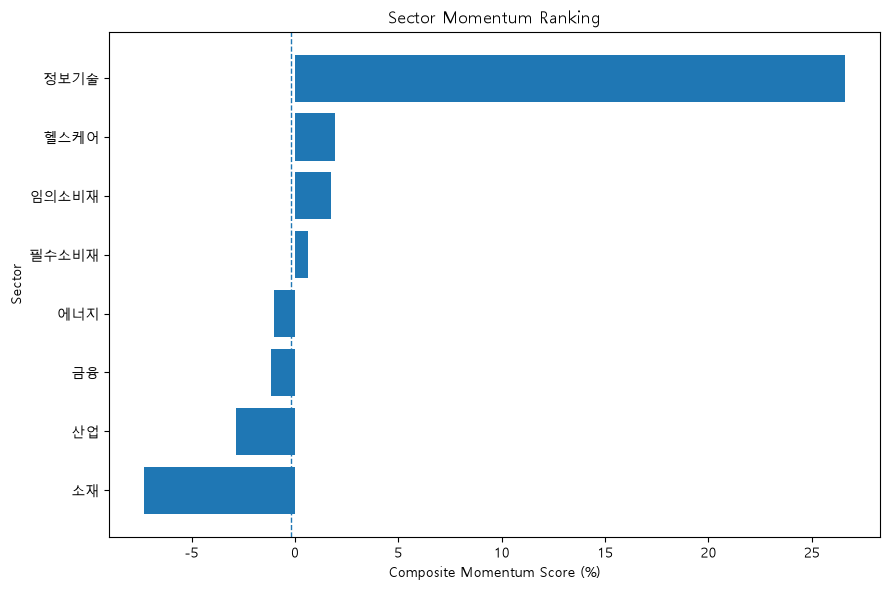

In [117]:
#sector momentum Bar chart
import matplotlib.pyplot as plt

plot_df = (
    sector_result
    .sort_values(
        "Composite (%)",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df.index,
    plot_df["Composite (%)"]
)

plt.axvline(
    x=momentum_median * 100,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Composite Momentum Score (%)")
plt.ylabel("Sector")
plt.title("Sector Momentum Ranking")

plt.tight_layout()

plt.savefig(
    "final_sector_momentum_barchart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
# ==========================================
# 6. PCA용 최근 1년 수익률
# ==========================================

PCA_LOOKBACK = 252

date = pd.Timestamp("2020-01-02")
loc = price.index.get_loc(date)

start_loc = max(
    0,
    loc - PCA_LOOKBACK
)

price_window = price.iloc[
    start_loc:loc + 1
][momentum_codes].copy()

returns_window = price_window.pct_change(
    fill_method=None
)

missing_ratio = returns_window.isna().mean()

valid_pca_codes = (
    missing_ratio[
        missing_ratio <= 0.20
    ]
    .index
    .tolist()
)

returns_pca = returns_window[
    valid_pca_codes
].copy()

print("모멘텀 통과 종목:", len(momentum_codes))
print("PCA 사용 종목:", len(valid_pca_codes))
print("PCA 제외 종목:",
      len(momentum_codes) - len(valid_pca_codes))

모멘텀 통과 종목: 148
PCA 사용 종목: 139
PCA 제외 종목: 9


In [109]:
# ==========================================
# 7. 결측치 처리 + 표준화
# ==========================================

from sklearn.preprocessing import StandardScaler

returns_pca_filled = returns_pca.apply(
    lambda x: x.fillna(x.mean()),
    axis=0
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    returns_pca_filled
)

print("PCA 입력 shape:", X_scaled.shape)
print("남은 결측치:", pd.isna(X_scaled).sum())

PCA 입력 shape: (253, 139)
남은 결측치: 0


In [110]:
# ==========================================
# 8. Parallel Analysis
# ==========================================

from sklearn.decomposition import PCA
import numpy as np

np.random.seed(42)

N_ITER = 500

n_samples, n_features = X_scaled.shape

# 실제 데이터 PCA
pca_full = PCA()
pca_full.fit(X_scaled)

actual_eigenvalues = pca_full.explained_variance_

# 랜덤 데이터 eigenvalue 저장
random_eigenvalues = np.zeros(
    (N_ITER, len(actual_eigenvalues))
)

for i in range(N_ITER):

    random_data = np.random.normal(
        size=(n_samples, n_features)
    )

    random_pca = PCA()
    random_pca.fit(random_data)

    random_eigenvalues[i, :] = (
        random_pca.explained_variance_
    )

# 랜덤 데이터 고유값의 95 percentile
random_threshold = np.percentile(
    random_eigenvalues,
    95,
    axis=0
)

# 실제 eigenvalue > 랜덤 95% eigenvalue
significant_mask = (
    actual_eigenvalues >
    random_threshold
)

N_COMPONENTS_PA = significant_mask.sum()

print(
    "Parallel Analysis 선택 PC 수:",
    N_COMPONENTS_PA
)

Parallel Analysis 선택 PC 수: 6


In [111]:
parallel_df = pd.DataFrame({
    "PC": np.arange(
        1,
        len(actual_eigenvalues) + 1
    ),
    "Actual_Eigenvalue": actual_eigenvalues,
    "Random_95pct": random_threshold
})

parallel_df["Selected"] = (
    parallel_df["Actual_Eigenvalue"]
    >
    parallel_df["Random_95pct"]
)

print(parallel_df.head(30))

    PC  Actual_Eigenvalue  Random_95pct  Selected
0    1          26.958127      3.086640      True
1    2           5.228052      2.937216      True
2    3           4.272266      2.836974      True
3    4           3.838817      2.767463      True
4    5           3.081685      2.691104      True
5    6           2.836728      2.619756      True
6    7           2.474800      2.565371     False
7    8           2.413739      2.501483     False
8    9           2.268037      2.450144     False
9   10           2.146597      2.397243     False
10  11           1.985365      2.353375     False
11  12           1.958106      2.306731     False
12  13           1.928141      2.263864     False
13  14           1.859543      2.220204     False
14  15           1.830751      2.177621     False
15  16           1.779964      2.139953     False
16  17           1.693595      2.101703     False
17  18           1.688470      2.059863     False
18  19           1.653815      2.031619     False


In [112]:
# ==========================================
# 10. Parallel Analysis 기반 최종 PCA
# ==========================================

pca_final = PCA(
    n_components=N_COMPONENTS_PA
)

pca_final.fit(X_scaled)

print(
    "최종 PC 수:",
    N_COMPONENTS_PA
)

print(
    "최종 누적설명률:",
    round(
        pca_final.explained_variance_ratio_.sum(),
        4
    )
)

최종 PC 수: 6
최종 누적설명률: 0.3312


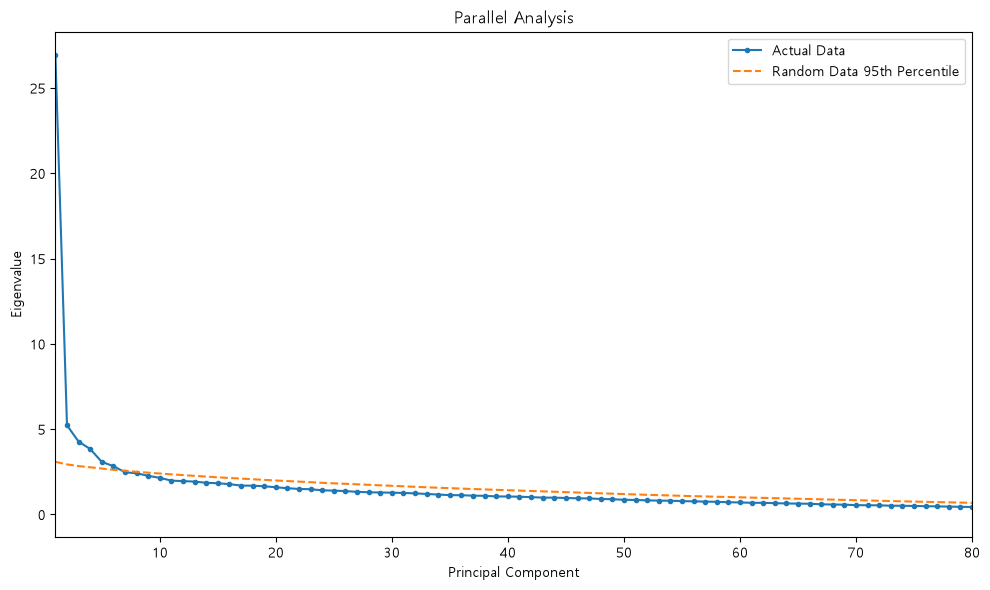

Parallel Analysis selected PCs: 6


In [118]:
#parrallel analysis plot
pc_num = np.arange(
    1,
    len(actual_eigenvalues) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    pc_num,
    actual_eigenvalues,
    marker="o",
    markersize=3,
    label="Actual Data"
)

plt.plot(
    pc_num,
    random_threshold,
    linestyle="--",
    label="Random Data 95th Percentile"
)

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Parallel Analysis")

plt.legend()

plt.xlim(
    1,
    min(80, len(pc_num))
)

plt.tight_layout()

plt.savefig(
    "final_parallel_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Parallel Analysis selected PCs:",
    N_COMPONENTS_PA
)

In [113]:
# ==========================================
# 11. 종목별 PCA Loading
# ==========================================

stock_loading_df = pd.DataFrame(
    pca_final.components_.T,
    index=valid_pca_codes,
    columns=[
        f"PC{i+1}"
        for i in range(N_COMPONENTS_PA)
    ]
)

print("Loading matrix shape:")
print(stock_loading_df.shape)

print("\n종목별 loading:")
print(stock_loading_df.head())

Loading matrix shape:
(139, 6)

종목별 loading:
             PC1       PC2       PC3       PC4       PC5       PC6
000270  0.029478 -0.021806  0.206247  0.240154 -0.166236 -0.025688
000660  0.103375 -0.147784 -0.048376  0.044114  0.064345  0.124231
000990  0.105566 -0.028238 -0.037535  0.016947  0.079570  0.121456
001820  0.122742 -0.074221 -0.021625 -0.050916  0.081571  0.087760
002070 -0.000386  0.015739 -0.021694  0.048650 -0.039466  0.101677


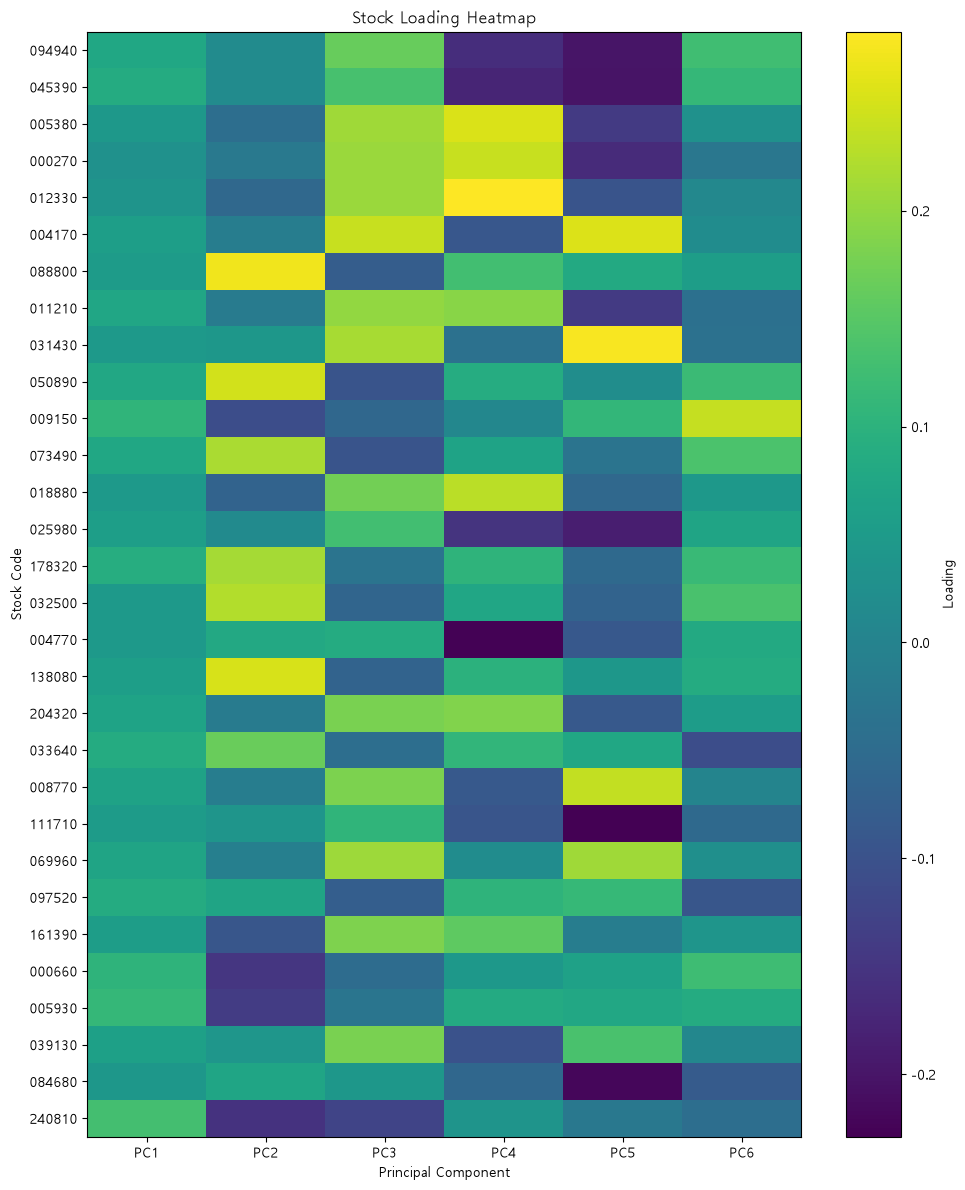

In [119]:
#loading heatmap
N_PC_HEATMAP = min(
    8,
    N_COMPONENTS_PA
)

loading_subset = (
    stock_loading_df
    .iloc[:, :N_PC_HEATMAP]
)

# 주요 PC에서 절대 loading 합이 큰 종목 30개
top_loading_stocks = (
    loading_subset
    .abs()
    .sum(axis=1)
    .nlargest(30)
    .index
)

heatmap_data = (
    loading_subset
    .loc[top_loading_stocks]
)

plt.figure(figsize=(10, 12))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(
    label="Loading"
)

plt.xticks(
    range(N_PC_HEATMAP),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data)),
    heatmap_data.index
)

plt.xlabel("Principal Component")
plt.ylabel("Stock Code")
plt.title("Stock Loading Heatmap")

plt.tight_layout()

plt.savefig(
    "final_loading_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [114]:
# ==========================================
# 12. Loading 기반 Ward 군집 수 비교
# ==========================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

X_loading = stock_loading_df.values

cluster_compare = []

for k in range(2, 11):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(
        X_loading
    )

    silhouette = silhouette_score(
        X_loading,
        labels
    )

    counts = pd.Series(
        labels
    ).value_counts()

    cluster_compare.append({
        "k": k,
        "silhouette": silhouette,
        "min_cluster_size": counts.min(),
        "max_cluster_size": counts.max(),
        "avg_cluster_size": counts.mean()
    })

cluster_compare_df = pd.DataFrame(
    cluster_compare
)

print(cluster_compare_df)

    k  silhouette  min_cluster_size  max_cluster_size  avg_cluster_size
0   2    0.319803                10               129         69.500000
1   3    0.168842                10                65         46.333333
2   4    0.150886                10                65         34.750000
3   5    0.184439                 7                58         27.800000
4   6    0.213631                 5                53         23.166667
5   7    0.233987                 5                47         19.857143
6   8    0.244211                 5                35         17.375000
7   9    0.236409                 5                34         15.444444
8  10    0.230085                 5                34         13.900000


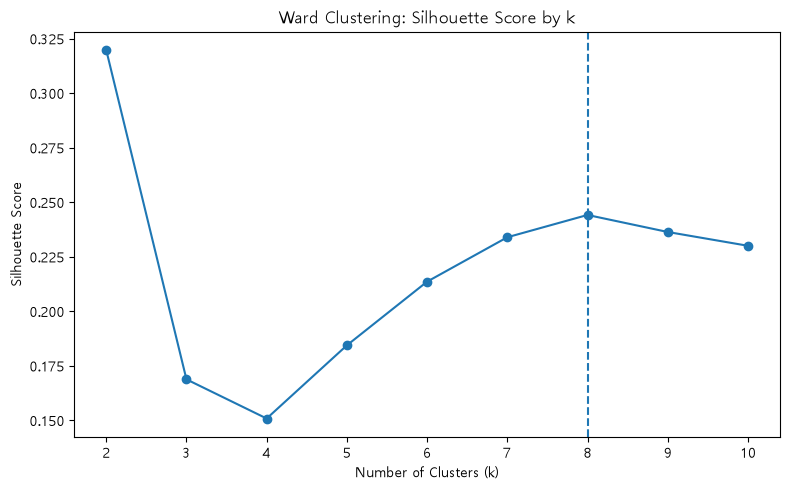

In [120]:
#k별 silhouette score
plt.figure(figsize=(8, 5))

plt.plot(
    cluster_compare_df["k"],
    cluster_compare_df["silhouette"],
    marker="o"
)

plt.axvline(
    x=8,
    linestyle="--"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Ward Clustering: Silhouette Score by k")

plt.xticks(
    cluster_compare_df["k"]
)

plt.tight_layout()

plt.savefig(
    "final_silhouette_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [115]:
# ==========================================
# 최종 Loading 기반 Ward Clustering
# ==========================================

FINAL_K = 8

final_cluster_model = AgglomerativeClustering(
    n_clusters=FINAL_K,
    linkage="ward"
)

cluster_labels = final_cluster_model.fit_predict(
    X_loading
)

stock_cluster_df = pd.DataFrame({
    "종목코드": valid_pca_codes,
    "cluster": cluster_labels
})

print("최종 군집 수:", FINAL_K)

print("\n군집별 종목 수:")
print(
    stock_cluster_df["cluster"]
    .value_counts()
    .sort_index()
)

최종 군집 수: 8

군집별 종목 수:
cluster
0    35
1    10
2    34
3    29
4     7
5     5
6     6
7    13
Name: count, dtype: int64


In [121]:
# ==========================================
# 종목별 1M / 3M / 6M / 12M Composite Momentum
# ==========================================

date = pd.Timestamp("2020-01-02")
loc = price.index.get_loc(date)

horizons = {
    "1M": 21,
    "3M": 63,
    "6M": 126,
    "12M": 252
}

stock_momentum_list = []

for code in valid_pca_codes:

    current_price = price.loc[date, code]

    row = {
        "종목코드": code
    }

    for name, lag in horizons.items():

        if loc >= lag:

            past_price = price.iloc[loc - lag][code]

            if (
                pd.notna(current_price)
                and pd.notna(past_price)
                and past_price != 0
            ):
                row[name] = current_price / past_price - 1

            else:
                row[name] = np.nan

        else:
            row[name] = np.nan

    # 네 기간이 모두 존재하는 종목만 Composite 계산
    values = [row["1M"], row["3M"], row["6M"], row["12M"]]

    if all(pd.notna(x) for x in values):
        row["Composite"] = np.mean(values)
    else:
        row["Composite"] = np.nan

    stock_momentum_list.append(row)


stock_momentum_df = pd.DataFrame(stock_momentum_list)

print(stock_momentum_df.head())
print(
    "\nComposite 계산 가능한 종목:",
    stock_momentum_df["Composite"].notna().sum()
)

     종목코드        1M        3M        6M       12M  Composite
0  000270 -0.017341 -0.067982 -0.034091  0.257396   0.034496
1  000660  0.170581  0.152068  0.362590  0.616041   0.325320
2  000990  0.468421  0.743750  0.891525  1.571429   0.918781
3  001820  0.190045  0.068020  0.019380  0.001905   0.069838
4  002070  0.027295  0.186246  2.044118  2.306709   1.141092

Composite 계산 가능한 종목: 139


In [122]:
# ==========================================
# 군집 + Momentum 연결
# ==========================================

cluster_momentum_df = stock_cluster_df.merge(
    stock_momentum_df,
    on="종목코드",
    how="left"
)

# Composite가 존재하는 종목만
cluster_momentum_valid = (
    cluster_momentum_df
    .dropna(subset=["Composite"])
    .copy()
)

# 각 군집에서 Composite Momentum 최고 종목
representative_df = (
    cluster_momentum_valid
    .sort_values(
        ["cluster", "Composite"],
        ascending=[True, False]
    )
    .groupby("cluster")
    .first()
    .reset_index()
)

print(
    representative_df[
        [
            "cluster",
            "종목코드",
            "1M",
            "3M",
            "6M",
            "12M",
            "Composite"
        ]
    ].to_string(index=False)
)

 cluster   종목코드       1M        3M        6M       12M  Composite
       0 040910 0.076923  0.333333  0.875598  1.722222   0.752019
       1 021240 0.004464  0.063830  0.162791  0.145038   0.094031
       2 088290 0.174757  6.089844  3.972603 14.000000   6.059301
       3 002070 0.027295  0.186246  2.044118  2.306709   1.141092
       4 084680 0.100394  0.809061  0.736025  1.121442   0.691731
       5 008770 0.109799  0.090487 -0.030928  0.258367   0.106931
       6 138080 0.123523 -0.074336 -0.016917  2.644599   0.669217
       7 097520 0.376623  0.565401  0.290435  2.016260   0.812180


In [123]:
# 종목 정보 추가
representative_detail = (
    representative_df
    .merge(
        info[["코드", "코드명"]],
        left_on="종목코드",
        right_on="코드",
        how="left"
    )
    .merge(
        sector_map[
            ["종목코드", "섹터명"]
        ],
        on="종목코드",
        how="left"
    )
)

# 수동 보완 섹터가 있으면 적용
representative_detail["섹터명"] = representative_detail.apply(
    lambda row:
        manual_sector.get(
            row["종목코드"],
            row["섹터명"]
        )
        if pd.isna(row["섹터명"])
        else row["섹터명"],
    axis=1
)

representative_detail["시가총액_백만원"] = (
    representative_detail["종목코드"]
    .map(mcap.loc[date])
)

representative_detail["Composite(%)"] = (
    representative_detail["Composite"] * 100
).round(2)

print(
    representative_detail[
        [
            "cluster",
            "종목코드",
            "코드명",
            "섹터명",
            "Composite(%)",
            "시가총액_백만원"
        ]
    ].to_string(index=False)
)

 cluster   종목코드   코드명   섹터명  Composite(%)   시가총액_백만원
       0 040910  아이씨디  정보기술         75.20  343391.57
       1 021240   코웨이 임의소비재          9.40 6641965.71
       2 088290 이원컴포텍 임의소비재        605.93  258598.77
       3 002070   비비안 임의소비재        114.11  142166.46
       4 084680   이월드 임의소비재         69.17  505950.32
       5 008770  호텔신라 임의소비재         10.69 3689323.37
       6 138080 오이솔루션  정보기술         66.92  404777.52
       7 097520  엠씨넥스  정보기술         81.22  662735.18


In [125]:
# ==========================================
# 각 군집 Composite Momentum 상위 3개 후보
# ==========================================

TOP_PER_CLUSTER = 3

cluster_candidates = (
    cluster_momentum_valid
    .sort_values(
        ["cluster", "Composite"],
        ascending=[True, False]
    )
    .groupby("cluster")
    .head(TOP_PER_CLUSTER)
    .reset_index(drop=True)
)

# 종목 정보 연결
cluster_candidates = (
    cluster_candidates
    .merge(
        info[["코드", "코드명"]],
        left_on="종목코드",
        right_on="코드",
        how="left"
    )
    .merge(
        sector_map[
            ["종목코드", "섹터명"]
        ],
        on="종목코드",
        how="left"
    )
)

# 수동 섹터 보완
cluster_candidates["섹터명"] = cluster_candidates.apply(
    lambda row:
        manual_sector.get(
            row["종목코드"],
            row["섹터명"]
        )
        if pd.isna(row["섹터명"])
        else row["섹터명"],
    axis=1
)

# 시가총액
cluster_candidates["시가총액_백만원"] = (
    cluster_candidates["종목코드"]
    .map(mcap.loc[date])
)

cluster_candidates["Composite(%)"] = (
    cluster_candidates["Composite"] * 100
).round(2)

print("MVO 후보 종목 수:", len(cluster_candidates))

print(
    cluster_candidates[
        [
            "cluster",
            "종목코드",
            "코드명",
            "섹터명",
            "Composite(%)",
            "시가총액_백만원"
        ]
    ].to_string(index=False)
)

print("\n시가총액 1조 이상 종목 수:")
print(
    (
        cluster_candidates["시가총액_백만원"]
        >= 1_000_000
    ).sum()
)

print("\n섹터별 후보 수:")
print(
    cluster_candidates["섹터명"]
    .value_counts()
)

MVO 후보 종목 수: 24
 cluster   종목코드      코드명   섹터명  Composite(%)    시가총액_백만원
       0 040910     아이씨디  정보기술         75.20   343391.57
       0 066310    큐에스아이  정보기술         74.15   112997.84
       0 281820     케이씨텍  정보기술         62.89   457296.79
       1 021240      코웨이 임의소비재          9.40  6641965.71
       1 012330    현대모비스 임의소비재          7.02 23588406.77
       1 204320     HL만도 임의소비재          6.66  1638803.49
       2 088290    이원컴포텍 임의소비재        605.93   258598.77
       2 230240    에치에프알  정보기술        373.35   357064.20
       2 082270      젬백스  정보기술        183.19  1556638.28
       3 002070      비비안 임의소비재        114.11   142166.46
       3 000990    DB하이텍  정보기술         91.88  1238720.61
       3 007810   코리아써키트  정보기술         90.10   283449.01
       4 084680      이월드 임의소비재         69.17   505950.32
       4 111710     남화산업 임의소비재         54.94   302643.60
       4 004770     써니전자  정보기술         54.58   168626.23
       5 008770     호텔신라 임의소비재         10.69  3689323.37
       5 031430

In [126]:
# ==========================================
# MVO 제약조건 가능 여부 확인
# ==========================================

large_cap = cluster_candidates[
    cluster_candidates["시가총액_백만원"] >= 1_000_000
].copy()

small_cap = cluster_candidates[
    cluster_candidates["시가총액_백만원"] < 1_000_000
].copy()

print("전체 후보:", len(cluster_candidates))
print("시총 1조 이상:", len(large_cap))
print("시총 1조 미만:", len(small_cap))

print("\n[시총 1조 이상 종목]")
print(
    large_cap[
        ["종목코드", "코드명", "섹터명", "시가총액_백만원"]
    ].to_string(index=False)
)

print("\n[1조 이상 종목의 섹터 분포]")
print(large_cap["섹터명"].value_counts())

전체 후보: 24
시총 1조 이상: 9
시총 1조 미만: 15

[시총 1조 이상 종목]
  종목코드      코드명   섹터명    시가총액_백만원
021240      코웨이 임의소비재  6641965.71
012330    현대모비스 임의소비재 23588406.77
204320     HL만도 임의소비재  1638803.49
082270      젬백스  정보기술  1556638.28
000990    DB하이텍  정보기술  1238720.61
008770     호텔신라 임의소비재  3689323.37
031430 신세계인터내셔날 임의소비재  1570800.00
004170      신세계 임의소비재  2879715.44
032500   케이엠더블유  정보기술  2280727.71

[1조 이상 종목의 섹터 분포]
섹터명
임의소비재    6
정보기술     3
Name: count, dtype: int64


In [127]:
# ============================================================
# Minimum Variance Optimization
# 제약:
# 1) Long Only
# 2) Sum(weights) = 1
# 3) Individual weight <= 20%
# 4) Sector weight <= 60%
# 5) Market cap < 1조 종목 합계 <= 30%
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize

# ------------------------------------------------------------
# 1. MVO 후보 종목
# ------------------------------------------------------------

candidate_codes = cluster_candidates["종목코드"].tolist()

# 최근 1년 일간수익률
candidate_returns = returns_pca_filled[
    candidate_codes
].copy()

# 공분산 행렬
cov_matrix = candidate_returns.cov().values

# 연율화 공분산
cov_matrix_annual = cov_matrix * 252

n_assets = len(candidate_codes)

print("MVO 후보 종목 수:", n_assets)


# ------------------------------------------------------------
# 2. 제약조건 설정
# ------------------------------------------------------------

MAX_STOCK_WEIGHT = 0.20     # 종목당 최대 20%
MAX_SECTOR_WEIGHT = 0.60    # 섹터당 최대 60%
MAX_SMALL_CAP_WEIGHT = 0.30 # 시총 1조 미만 합계 최대 30%

# 종목별 섹터
sector_array = (
    cluster_candidates
    .set_index("종목코드")
    .loc[candidate_codes, "섹터명"]
)

# 종목별 시가총액
mcap_array = (
    cluster_candidates
    .set_index("종목코드")
    .loc[candidate_codes, "시가총액_백만원"]
    .values
)

# 시총 1조 미만 여부
small_cap_mask = (
    mcap_array < 1_000_000
)


# ------------------------------------------------------------
# 3. 목적함수: 포트폴리오 분산 최소화
# ------------------------------------------------------------

def portfolio_variance(weights):
    return weights @ cov_matrix_annual @ weights


# ------------------------------------------------------------
# 4. 제약식
# ------------------------------------------------------------

constraints = []

# 총 투자비중 = 1
constraints.append({
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
})

# 시총 1조 미만 종목 합 <= 30%
constraints.append({
    "type": "ineq",
    "fun": lambda w: (
        MAX_SMALL_CAP_WEIGHT
        - np.sum(w[small_cap_mask])
    )
})

# 섹터별 최대 60%
for sector in sector_array.unique():

    sector_mask = (
        sector_array.values == sector
    )

    constraints.append({
        "type": "ineq",
        "fun": lambda w, mask=sector_mask: (
            MAX_SECTOR_WEIGHT
            - np.sum(w[mask])
        )
    })


# ------------------------------------------------------------
# 5. 종목별 bounds
# ------------------------------------------------------------

bounds = [
    (0, MAX_STOCK_WEIGHT)
    for _ in range(n_assets)
]


# ------------------------------------------------------------
# 6. 초기값
#    대형주 70%, 소형주 30%로 시작
# ------------------------------------------------------------

large_cap_mask = ~small_cap_mask

x0 = np.zeros(n_assets)

x0[large_cap_mask] = (
    0.70 / large_cap_mask.sum()
)

x0[small_cap_mask] = (
    0.30 / small_cap_mask.sum()
)

print("\n초기 비중 합:", x0.sum())

print(
    "초기 소형주 비중:",
    x0[small_cap_mask].sum()
)

for sector in sector_array.unique():

    mask = (
        sector_array.values == sector
    )

    print(
        f"초기 {sector} 비중:",
        round(x0[mask].sum(), 4)
    )


# ------------------------------------------------------------
# 7. 최적화
# ------------------------------------------------------------

result = minimize(
    portfolio_variance,
    x0=x0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "maxiter": 2000,
        "ftol": 1e-12,
        "disp": False
    }
)

print("\n최적화 성공 여부:", result.success)
print("메시지:", result.message)


# ------------------------------------------------------------
# 8. 최적 비중
# ------------------------------------------------------------

mvo_weights = result.x

weight_df = cluster_candidates[
    [
        "종목코드",
        "코드명",
        "섹터명",
        "시가총액_백만원"
    ]
].copy()

weight_df["Weight"] = mvo_weights

weight_df["Weight(%)"] = (
    weight_df["Weight"] * 100
).round(2)

weight_df = (
    weight_df
    .sort_values(
        "Weight",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n========== 최종 MVO 비중 ==========")

print(
    weight_df[
        [
            "종목코드",
            "코드명",
            "섹터명",
            "시가총액_백만원",
            "Weight(%)"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 9. 제약조건 최종 확인
# ------------------------------------------------------------

print("\n========== 제약조건 확인 ==========")

print(
    "총 투자비중:",
    round(mvo_weights.sum(), 6)
)

print(
    "최대 개별 종목 비중:",
    round(mvo_weights.max(), 4)
)

print(
    "시총 1조 미만 종목 합계:",
    round(
        mvo_weights[small_cap_mask].sum(),
        4
    )
)

for sector in sector_array.unique():

    mask = (
        sector_array.values == sector
    )

    print(
        f"{sector} 비중:",
        round(
            mvo_weights[mask].sum(),
            4
        )
    )


# ------------------------------------------------------------
# 10. MVO 예상 연율 변동성
# ------------------------------------------------------------

mvo_volatility = np.sqrt(
    portfolio_variance(mvo_weights)
)

print(
    "\nMVO 예상 연율 변동성:",
    round(mvo_volatility * 100, 2),
    "%"
)

MVO 후보 종목 수: 24

초기 비중 합: 1.0
초기 소형주 비중: 0.3
초기 정보기술 비중: 0.4333
초기 임의소비재 비중: 0.5667

최적화 성공 여부: True
메시지: Optimization terminated successfully

========== 최종 MVO 비중 ==========
  종목코드      코드명   섹터명    시가총액_백만원  Weight(%)
021240      코웨이 임의소비재  6641965.71      20.00
012330    현대모비스 임의소비재 23588406.77      20.00
004170      신세계 임의소비재  2879715.44      13.46
097520     엠씨넥스  정보기술   662735.18       8.06
000990    DB하이텍  정보기술  1238720.61       7.98
004770     써니전자  정보기술   168626.23       5.57
007810   코리아써키트  정보기술   283449.01       4.55
032500   케이엠더블유  정보기술  2280727.71       4.37
040910     아이씨디  정보기술   343391.57       2.41
281820     케이씨텍  정보기술   457296.79       2.20
138080    오이솔루션  정보기술   404777.52       2.18
008770     호텔신라 임의소비재  3689323.37       1.88
066310    큐에스아이  정보기술   112997.84       1.84
084680      이월드 임의소비재   505950.32       1.52
002070      비비안 임의소비재   142166.46       1.50
204320     HL만도 임의소비재  1638803.49       1.46
082270      젬백스  정보기술  1556638.28       0.85
088290    이원컴포

In [128]:
# ============================================================
# Equal Weight vs Minimum Variance 비교
# ============================================================

# 1. 동일비중
equal_weights = np.repeat(
    1 / n_assets,
    n_assets
)

# 2. 동일비중 연율 변동성
equal_variance = (
    equal_weights
    @ cov_matrix_annual
    @ equal_weights
)

equal_volatility = np.sqrt(equal_variance)

# 3. MVO 변동성은 앞에서 계산한 값 사용
print("Equal Weight 연율 변동성:",
      round(equal_volatility * 100, 2), "%")

print("Minimum Variance 연율 변동성:",
      round(mvo_volatility * 100, 2), "%")

risk_reduction = (
    1 - mvo_volatility / equal_volatility
) * 100

print("변동성 감소율:",
      round(risk_reduction, 2), "%")


# ============================================================
# 비교 표
# ============================================================

vol_compare = pd.DataFrame({
    "Portfolio": [
        "Equal Weight",
        "Minimum Variance"
    ],
    "Annualized Volatility (%)": [
        equal_volatility * 100,
        mvo_volatility * 100
    ]
})

vol_compare["Annualized Volatility (%)"] = (
    vol_compare["Annualized Volatility (%)"]
    .round(2)
)

print("\n[변동성 비교]")
print(vol_compare)


# ============================================================
# 최종 Weight 표 저장
# ============================================================

final_weight_table = weight_df[
    [
        "종목코드",
        "코드명",
        "섹터명",
        "시가총액_백만원",
        "Weight(%)"
    ]
].copy()

final_weight_table.to_excel(
    "final_minimum_variance_weights.xlsx",
    index=False
)

vol_compare.to_excel(
    "equal_vs_mvo_volatility.xlsx",
    index=False
)

print("\n결과표 저장 완료")

Equal Weight 연율 변동성: 30.67 %
Minimum Variance 연율 변동성: 17.47 %
변동성 감소율: 43.02 %

[변동성 비교]
          Portfolio  Annualized Volatility (%)
0      Equal Weight                      30.67
1  Minimum Variance                      17.47

결과표 저장 완료


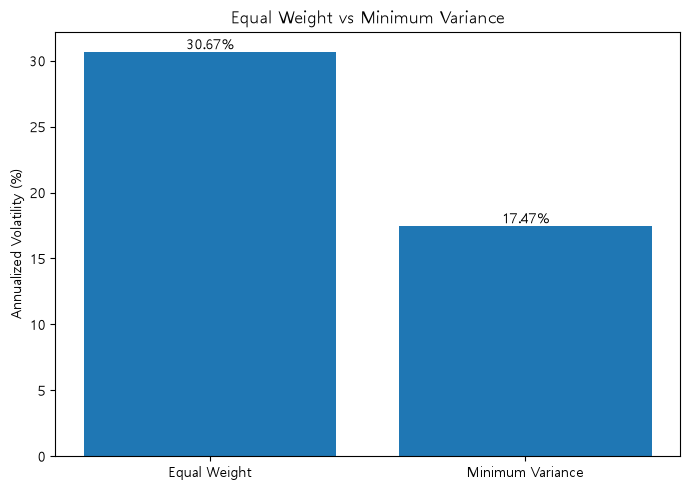

In [129]:
# ============================================================
# Equal Weight vs MVO 변동성 비교 그래프
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    vol_compare["Portfolio"],
    vol_compare["Annualized Volatility (%)"]
)

plt.ylabel("Annualized Volatility (%)")
plt.title("Equal Weight vs Minimum Variance")

# 숫자 표시
for i, value in enumerate(
    vol_compare["Annualized Volatility (%)"]
):
    plt.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "equal_vs_mvo_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [130]:
# ============================================================
# 백테스트 1단계
# 월말 리밸런싱 날짜 생성
# ============================================================

BACKTEST_LOOKBACK = 252

# 최소 252거래일 데이터가 확보된 날짜 이후부터 사용
eligible_dates = price.index[BACKTEST_LOOKBACK:]

# 각 월의 마지막 거래일
rebalance_dates = (
    pd.Series(eligible_dates, index=eligible_dates)
    .groupby(eligible_dates.to_period("M"))
    .last()
    .tolist()
)

print("리밸런싱 횟수:", len(rebalance_dates))
print("첫 리밸런싱 날짜:", rebalance_dates[0])
print("마지막 리밸런싱 날짜:", rebalance_dates[-1])

print("\n앞쪽 리밸런싱 날짜:")
print(rebalance_dates[:12])

리밸런싱 횟수: 102
첫 리밸런싱 날짜: 2018-04-30 00:00:00
마지막 리밸런싱 날짜: 2026-09-28 00:00:00

앞쪽 리밸런싱 날짜:
[Timestamp('2018-04-30 00:00:00'), Timestamp('2018-05-31 00:00:00'), Timestamp('2018-06-29 00:00:00'), Timestamp('2018-07-31 00:00:00'), Timestamp('2018-08-31 00:00:00'), Timestamp('2018-09-28 00:00:00'), Timestamp('2018-10-31 00:00:00'), Timestamp('2018-11-30 00:00:00'), Timestamp('2018-12-28 00:00:00'), Timestamp('2019-01-31 00:00:00'), Timestamp('2019-02-28 00:00:00'), Timestamp('2019-03-29 00:00:00')]


In [131]:
# ============================================================
# 백테스트 2단계
# 날짜별 섹터 모멘텀 + 전략 유니버스 자동 생성
# ============================================================

def get_strategy_universe(date):

    date = pd.Timestamp(date)

    # --------------------------------------------------------
    # 1. ETF별 1M / 3M / 6M / 12M 수익률
    # --------------------------------------------------------

    if date not in sector_etf.index:
        raise ValueError(f"{date.date()}가 sector_etf 데이터에 없습니다.")

    loc_etf = sector_etf.index.get_loc(date)

    horizons = {
        "1M": 21,
        "3M": 63,
        "6M": 126,
        "12M": 252
    }

    etf_result = {}

    for etf in sector_etf.columns:

        current = sector_etf.loc[date, etf]

        temp = {}

        for name, lag in horizons.items():

            if loc_etf >= lag:

                past = sector_etf.iloc[loc_etf - lag][etf]

                if (
                    pd.notna(current)
                    and pd.notna(past)
                    and past != 0
                ):
                    temp[name] = current / past - 1
                else:
                    temp[name] = np.nan

            else:
                temp[name] = np.nan

        etf_result[etf] = temp


    etf_momentum = pd.DataFrame(etf_result).T


    # --------------------------------------------------------
    # 2. ETF → 8개 대분류 섹터
    # --------------------------------------------------------

    sector_result = {}

    for sector, etfs in sector_etf_map.items():

        sector_result[sector] = (
            etf_momentum.loc[
                etfs,
                ["1M", "3M", "6M", "12M"]
            ]
            .mean(axis=0)
        )

    sector_result = pd.DataFrame(sector_result).T


    # --------------------------------------------------------
    # 3. Composite Momentum
    # --------------------------------------------------------

    sector_result["Composite"] = (
        sector_result[
            ["1M", "3M", "6M", "12M"]
        ]
        .mean(axis=1)
    )

    momentum_median = sector_result["Composite"].median()


    # --------------------------------------------------------
    # 4. 섹터 선택 조건
    #
    # 조건 1: 12개월 실제 수익률 > 0
    # 조건 2: Composite >= 전체 섹터 중앙값
    # --------------------------------------------------------

    sector_result["Positive_12M"] = (
        sector_result["12M"] > 0
    )

    sector_result["Above_Median"] = (
        sector_result["Composite"] >= momentum_median
    )

    sector_result["Selected"] = (
        sector_result["Positive_12M"]
        &
        sector_result["Above_Median"]
    )

    selected_sectors = (
        sector_result[
            sector_result["Selected"]
        ]
        .index
        .tolist()
    )


    # --------------------------------------------------------
    # 5. 그 날짜의 기본 투자 가능 유니버스
    # --------------------------------------------------------

    base_codes = get_universe(date)


    # --------------------------------------------------------
    # 6. 해당 날짜에 실제 존재한 종목명 붙이기
    # --------------------------------------------------------

    active_info = info[
        (info["최초상장일"] <= date)
        &
        (
            info["상장폐지일"].isna()
            |
            (info["상장폐지일"] > date)
        )
    ].copy()

    active_info = (
        active_info
        .drop_duplicates(
            subset=["코드"],
            keep="last"
        )
    )

    name_map = (
        active_info
        .set_index("코드")["코드명"]
    )

    universe_df = pd.DataFrame({
        "종목코드": base_codes
    })

    universe_df["종목명"] = (
        universe_df["종목코드"]
        .map(name_map)
    )


    # --------------------------------------------------------
    # 7. 우선주 제외
    # --------------------------------------------------------

    preferred_mask = (
        universe_df["종목명"]
        .astype(str)
        .str.contains(
            r"우$|우B$|우C$|우선주",
            regex=True,
            na=False
        )
    )

    universe_df = (
        universe_df[
            ~preferred_mask
        ]
        .copy()
    )


    # --------------------------------------------------------
    # 8. 섹터 정보 연결
    # --------------------------------------------------------

    universe_df = universe_df.merge(
        sector_map[
            ["종목코드", "섹터명"]
        ],
        on="종목코드",
        how="left"
    )

    # 과거 상폐 종목 수동 보완
    universe_df["섹터명"] = universe_df.apply(
        lambda row:
            manual_sector.get(
                row["종목코드"],
                row["섹터명"]
            )
            if pd.isna(row["섹터명"])
            else row["섹터명"],
        axis=1
    )


    # --------------------------------------------------------
    # 9. 선택된 섹터 종목만 남기기
    # --------------------------------------------------------

    final_df = universe_df[
        universe_df["섹터명"].isin(
            selected_sectors
        )
    ].copy()


    return {
        "sector_result": sector_result,
        "selected_sectors": selected_sectors,
        "universe": final_df
    }

In [132]:
test_result = get_strategy_universe(
    pd.Timestamp("2020-01-31")
)

print("선택 섹터:")
print(test_result["selected_sectors"])

print(
    "\n전략 후보 종목 수:",
    len(test_result["universe"])
)

print("\n섹터별 종목 수:")
print(
    test_result["universe"]["섹터명"]
    .value_counts()
)

print("\n섹터 모멘텀:")
print(
    test_result["sector_result"]
    .sort_values(
        "Composite",
        ascending=False
    )
)

선택 섹터:
['정보기술']

전략 후보 종목 수: 126

섹터별 종목 수:
섹터명
정보기술    126
Name: count, dtype: int64

섹터 모멘텀:
             1M        3M        6M       12M  Composite  Positive_12M  \
정보기술  -0.011196  0.119020  0.195386  0.309399   0.153152          True   
필수소비재 -0.030534  0.007665 -0.012910 -0.065361  -0.025285         False   
임의소비재 -0.070446 -0.065402 -0.046094 -0.041962  -0.055976         False   
헬스케어  -0.049808 -0.043671 -0.023331 -0.199797  -0.079152         False   
금융    -0.104624 -0.028974 -0.110353 -0.129531  -0.093370         False   
산업    -0.078266 -0.053869 -0.066645 -0.183948  -0.095682         False   
에너지   -0.075041 -0.055923 -0.103517 -0.161963  -0.099111         False   
소재    -0.067870 -0.046529 -0.168973 -0.237786  -0.130290         False   

       Above_Median  Selected  
정보기술           True      True  
필수소비재          True     False  
임의소비재          True     False  
헬스케어           True     False  
금융            False     False  
산업            False     False  
에너지           

In [133]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.optimize import minimize

np.random.seed(42)

# ============================================================
# 설정
# ============================================================

LOOKBACK = 252
MAX_STOCK_WEIGHT = 0.20
MAX_SECTOR_WEIGHT = 0.60
MAX_SMALL_CAP_WEIGHT = 0.30
SMALL_CAP_THRESHOLD = 1_000_000   # 백만원 = 1조원

PARALLEL_ITER = 100   # 백테스트 속도 위해 100회
TOP_PER_CLUSTER = 3

# ============================================================
# 종목별 모멘텀 계산 함수
# ============================================================

def calc_stock_composite(date, codes):

    loc = price.index.get_loc(date)

    horizons = {
        "1M": 21,
        "3M": 63,
        "6M": 126,
        "12M": 252
    }

    rows = []

    for code in codes:

        current = price.loc[date, code]

        vals = {}
        ok = True

        for name, lag in horizons.items():

            if loc < lag:
                ok = False
                break

            past = price.iloc[loc - lag][code]

            if pd.isna(current) or pd.isna(past) or past == 0:
                ok = False
                break

            vals[name] = current / past - 1

        if ok:

            rows.append({
                "종목코드": code,
                "1M": vals["1M"],
                "3M": vals["3M"],
                "6M": vals["6M"],
                "12M": vals["12M"],
                "Composite": np.mean(list(vals.values()))
            })

    return pd.DataFrame(rows)


# ============================================================
# Parallel Analysis
# ============================================================

def parallel_analysis(X, n_iter=100):

    pca_real = PCA()
    pca_real.fit(X)

    actual = pca_real.explained_variance_

    random_eigs = []

    for _ in range(n_iter):

        rnd = np.random.normal(size=X.shape)

        pca_rnd = PCA()
        pca_rnd.fit(rnd)

        random_eigs.append(
            pca_rnd.explained_variance_
        )

    random_eigs = np.array(random_eigs)

    threshold = np.percentile(
        random_eigs,
        95,
        axis=0
    )

    n_pc = int(
        np.sum(actual > threshold)
    )

    return max(n_pc, 1)


# ============================================================
# 한 시점 후보 종목 생성
# ============================================================

def build_mvo_candidates(date):

    strategy = get_strategy_universe(date)

    universe_df = strategy["universe"]

    if len(universe_df) < 10:
        return None

    codes = universe_df["종목코드"].tolist()

    loc = price.index.get_loc(date)

    if loc < LOOKBACK:
        return None

    # 최근 1년
    px = price.iloc[
        loc - LOOKBACK:loc + 1
    ][codes]

    ret = px.pct_change(fill_method=None)

    missing = ret.isna().mean()

    valid_codes = (
        missing[missing <= 0.20]
        .index
        .tolist()
    )

    if len(valid_codes) < 8:
        return None

    ret = ret[valid_codes]

    # 결측 대체
    ret_filled = ret.apply(
        lambda x: x.fillna(x.mean()),
        axis=0
    )

    # 표준화
    X = StandardScaler().fit_transform(
        ret_filled
    )

    # Parallel Analysis
    n_pc = parallel_analysis(
        X,
        n_iter=PARALLEL_ITER
    )

    pca = PCA(
        n_components=n_pc
    )

    pca.fit(X)

    # 종목 x PC loading
    loading_df = pd.DataFrame(
        pca.components_.T,
        index=valid_codes,
        columns=[
            f"PC{i+1}"
            for i in range(n_pc)
        ]
    )

    X_loading = loading_df.values

    # --------------------------------------------------------
    # 군집 수 선택
    # k=2는 너무 거칠 수 있으므로 3~10 중
    # silhouette 최대값 선택
    # --------------------------------------------------------

    max_k = min(
        10,
        len(valid_codes) - 1
    )

    best_k = None
    best_score = -np.inf

    for k in range(3, max_k + 1):

        model = AgglomerativeClustering(
            n_clusters=k,
            linkage="ward"
        )

        labels = model.fit_predict(
            X_loading
        )

        counts = pd.Series(
            labels
        ).value_counts()

        # 너무 작은 군집 방지
        if counts.min() < 3:
            continue

        score = silhouette_score(
            X_loading,
            labels
        )

        if score > best_score:
            best_score = score
            best_k = k

    if best_k is None:
        best_k = 3

    final_model = AgglomerativeClustering(
        n_clusters=best_k,
        linkage="ward"
    )

    labels = final_model.fit_predict(
        X_loading
    )

    cluster_df = pd.DataFrame({
        "종목코드": valid_codes,
        "cluster": labels
    })

    # 종목별 Composite
    stock_mom = calc_stock_composite(
        date,
        valid_codes
    )

    tmp = cluster_df.merge(
        stock_mom,
        on="종목코드",
        how="left"
    )

    tmp = tmp.dropna(
        subset=["Composite"]
    )

    # 군집별 상위 3개
    candidates = (
        tmp.sort_values(
            ["cluster", "Composite"],
            ascending=[True, False]
        )
        .groupby("cluster")
        .head(TOP_PER_CLUSTER)
        .copy()
    )

    if len(candidates) < 5:
        return None

    # 종목 정보
    active_info = info[
        (info["최초상장일"] <= date)
        &
        (
            info["상장폐지일"].isna()
            |
            (info["상장폐지일"] > date)
        )
    ].drop_duplicates(
        subset=["코드"],
        keep="last"
    )

    candidates = candidates.merge(
        active_info[
            ["코드", "코드명"]
        ],
        left_on="종목코드",
        right_on="코드",
        how="left"
    )

    candidates = candidates.merge(
        sector_map[
            ["종목코드", "섹터명"]
        ],
        on="종목코드",
        how="left"
    )

    candidates["섹터명"] = candidates.apply(
        lambda r:
            manual_sector.get(
                r["종목코드"],
                r["섹터명"]
            )
            if pd.isna(r["섹터명"])
            else r["섹터명"],
        axis=1
    )

    candidates["시가총액_백만원"] = (
        candidates["종목코드"]
        .map(mcap.loc[date])
    )

    candidates = candidates.dropna(
        subset=[
            "섹터명",
            "시가총액_백만원"
        ]
    )

    return candidates


# ============================================================
# MVO 함수
# ============================================================

def optimize_weights(date, candidates):

    codes = candidates[
        "종목코드"
    ].tolist()

    loc = price.index.get_loc(date)

    ret = (
        price.iloc[
            loc - LOOKBACK:loc + 1
        ][codes]
        .pct_change(fill_method=None)
        .apply(
            lambda x: x.fillna(x.mean()),
            axis=0
        )
    )

    cov = ret.cov().values * 252

    n = len(codes)

    sector_arr = (
        candidates
        .set_index("종목코드")
        .loc[codes, "섹터명"]
        .values
    )

    mcap_arr = (
        candidates
        .set_index("종목코드")
        .loc[codes, "시가총액_백만원"]
        .values
    )

    small_mask = (
        mcap_arr <
        SMALL_CAP_THRESHOLD
    )

    def obj(w):
        return w @ cov @ w

    constraints = [
        {
            "type": "eq",
            "fun": lambda w:
                np.sum(w) - 1
        }
    ]

    # 소형주 30%
    constraints.append({
        "type": "ineq",
        "fun": lambda w:
            MAX_SMALL_CAP_WEIGHT
            - np.sum(w[small_mask])
    })

    # 섹터 60%
    for sector in np.unique(sector_arr):

        mask = (
            sector_arr == sector
        )

        constraints.append({
            "type": "ineq",
            "fun": lambda w, m=mask:
                MAX_SECTOR_WEIGHT
                - np.sum(w[m])
        })

    bounds = [
        (0, MAX_STOCK_WEIGHT)
        for _ in range(n)
    ]

    # 초기값
    large_mask = ~small_mask

    x0 = np.repeat(
        1/n,
        n
    )

    # 초기값이 소형주 조건 위반하면 조정
    if small_mask.sum() > 0 and large_mask.sum() > 0:

        x0 = np.zeros(n)

        x0[large_mask] = (
            0.70 /
            large_mask.sum()
        )

        x0[small_mask] = (
            0.30 /
            small_mask.sum()
        )

    result = minimize(
        obj,
        x0=x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "maxiter": 1000,
            "ftol": 1e-10
        }
    )

    if not result.success:
        return None

    return pd.Series(
        result.x,
        index=codes
    )


# ============================================================
# 월별 백테스트
# ============================================================

mvo_monthly_returns = []
equal_monthly_returns = []

mvo_turnovers = []
equal_turnovers = []

prev_mvo_weights = None
prev_equal_weights = None

backtest_log = []

for i in range(
    len(rebalance_dates) - 1
):

    signal_date = rebalance_dates[i]
    next_rebalance = rebalance_dates[i + 1]

    try:

        candidates = build_mvo_candidates(
            signal_date
        )

        if (
            candidates is None
            or len(candidates) == 0
        ):
            continue

        mvo_w = optimize_weights(
            signal_date,
            candidates
        )

        if mvo_w is None:
            continue

        codes = mvo_w.index.tolist()

        # Equal Weight
        equal_w = pd.Series(
            1 / len(codes),
            index=codes
        )

        # ----------------------------------------------------
        # 다음 거래일부터 다음 리밸런싱일까지
        # ----------------------------------------------------

        signal_loc = price.index.get_loc(
            signal_date
        )

        next_loc = price.index.get_loc(
            next_rebalance
        )

        holding_prices = price.iloc[
            signal_loc + 1:
            next_loc + 1
        ][codes]

        daily_ret = (
            holding_prices
            .pct_change(fill_method=None)
        )

        # 첫날 수익률은 signal_date 가격 기준
        first_day = (
            holding_prices.iloc[0]
            / price.loc[
                signal_date,
                codes
            ]
            - 1
        )

        daily_ret.iloc[0] = first_day

        daily_ret = daily_ret.fillna(0)

        mvo_daily = (
            daily_ret
            @ mvo_w
        )

        equal_daily = (
            daily_ret
            @ equal_w
        )

        mvo_month_return = (
            (1 + mvo_daily).prod() - 1
        )

        equal_month_return = (
            (1 + equal_daily).prod() - 1
        )

        mvo_monthly_returns.append({
            "date": next_rebalance,
            "return": mvo_month_return
        })

        equal_monthly_returns.append({
            "date": next_rebalance,
            "return": equal_month_return
        })

        # ----------------------------------------------------
        # Turnover
        # ----------------------------------------------------

        if prev_mvo_weights is not None:

            all_codes = (
                prev_mvo_weights.index
                .union(mvo_w.index)
            )

            old = prev_mvo_weights.reindex(
                all_codes,
                fill_value=0
            )

            new = mvo_w.reindex(
                all_codes,
                fill_value=0
            )

            turnover = (
                np.abs(new - old).sum()
                / 2
            )

            mvo_turnovers.append(turnover)

        if prev_equal_weights is not None:

            all_codes = (
                prev_equal_weights.index
                .union(equal_w.index)
            )

            old = prev_equal_weights.reindex(
                all_codes,
                fill_value=0
            )

            new = equal_w.reindex(
                all_codes,
                fill_value=0
            )

            turnover = (
                np.abs(new - old).sum()
                / 2
            )

            equal_turnovers.append(turnover)

        prev_mvo_weights = mvo_w
        prev_equal_weights = equal_w

        backtest_log.append({
            "signal_date": signal_date,
            "holding_end": next_rebalance,
            "n_candidates": len(candidates),
            "n_assets": len(codes)
        })

        print(
            signal_date.date(),
            "→",
            next_rebalance.date(),
            "| 후보:",
            len(candidates),
            "| MVO 종목:",
            len(codes)
        )

    except Exception as e:

        print(
            "SKIP:",
            signal_date.date(),
            "|",
            e
        )


print("\n백테스트 완료")
print(
    "MVO 월 수익률 개수:",
    len(mvo_monthly_returns)
)
print(
    "Equal 월 수익률 개수:",
    len(equal_monthly_returns)
)

2018-04-30 → 2018-05-31 | 후보: 24 | MVO 종목: 24
2018-06-29 → 2018-07-31 | 후보: 24 | MVO 종목: 24
2018-07-31 → 2018-08-31 | 후보: 12 | MVO 종목: 12
2018-08-31 → 2018-09-28 | 후보: 30 | MVO 종목: 30
2018-09-28 → 2018-10-31 | 후보: 30 | MVO 종목: 30
2019-10-31 → 2019-11-29 | 후보: 24 | MVO 종목: 24
2019-11-29 → 2019-12-30 | 후보: 30 | MVO 종목: 30
2019-12-30 → 2020-01-31 | 후보: 27 | MVO 종목: 27
2020-05-29 → 2020-06-30 | 후보: 18 | MVO 종목: 18
2020-08-31 → 2020-09-29 | 후보: 24 | MVO 종목: 24
2020-09-29 → 2020-10-30 | 후보: 24 | MVO 종목: 24
2020-10-30 → 2020-11-30 | 후보: 21 | MVO 종목: 21
2020-11-30 → 2020-12-30 | 후보: 30 | MVO 종목: 30
2020-12-30 → 2021-01-29 | 후보: 21 | MVO 종목: 21
2021-01-29 → 2021-02-26 | 후보: 24 | MVO 종목: 24
2021-02-26 → 2021-03-31 | 후보: 21 | MVO 종목: 21
2021-03-31 → 2021-04-30 | 후보: 30 | MVO 종목: 30
2021-04-30 → 2021-05-31 | 후보: 30 | MVO 종목: 30
2021-05-31 → 2021-06-30 | 후보: 30 | MVO 종목: 30
2021-06-30 → 2021-07-30 | 후보: 30 | MVO 종목: 30
2021-07-30 → 2021-08-31 | 후보: 30 | MVO 종목: 30
2021-08-31 → 2021-09-30 | 후보: 30 |

In [134]:
# ============================================================
# 최종 성과지표 계산
# ============================================================

mvo_ret = pd.DataFrame(mvo_monthly_returns).set_index("date")["return"]
equal_ret = pd.DataFrame(equal_monthly_returns).set_index("date")["return"]

# 공통 기간 맞추기
common_idx = mvo_ret.index.intersection(equal_ret.index)

mvo_ret = mvo_ret.loc[common_idx]
equal_ret = equal_ret.loc[common_idx]


def performance_summary(monthly_returns, turnovers=None):

    n_months = len(monthly_returns)

    cumulative_return = (1 + monthly_returns).prod() - 1

    annual_return = (
        (1 + cumulative_return) ** (12 / n_months) - 1
    )

    annual_vol = (
        monthly_returns.std(ddof=1)
        * np.sqrt(12)
    )

    sharpe = (
        annual_return / annual_vol
        if annual_vol != 0
        else np.nan
    )

    cumulative_curve = (
        1 + monthly_returns
    ).cumprod()

    running_max = cumulative_curve.cummax()

    drawdown = (
        cumulative_curve / running_max - 1
    )

    mdd = drawdown.min()

    avg_turnover = (
        np.mean(turnovers)
        if turnovers is not None and len(turnovers) > 0
        else np.nan
    )

    return {
        "Cumulative Return (%)": cumulative_return * 100,
        "CAGR (%)": annual_return * 100,
        "Annualized Volatility (%)": annual_vol * 100,
        "Sharpe Ratio": sharpe,
        "MDD (%)": mdd * 100,
        "Average Turnover (%)": avg_turnover * 100
    }


mvo_summary = performance_summary(
    mvo_ret,
    mvo_turnovers
)

equal_summary = performance_summary(
    equal_ret,
    equal_turnovers
)

performance_table = pd.DataFrame(
    {
        "Minimum Variance": mvo_summary,
        "Equal Weight": equal_summary
    }
).T

print(performance_table.round(2))

                  Cumulative Return (%)  CAGR (%)  Annualized Volatility (%)  \
Minimum Variance                 -33.27     -6.89                      31.50   
Equal Weight                     -41.29     -8.97                      38.56   

                  Sharpe Ratio  MDD (%)  Average Turnover (%)  
Minimum Variance         -0.22   -41.08                 77.06  
Equal Weight             -0.23   -67.09                 67.15  


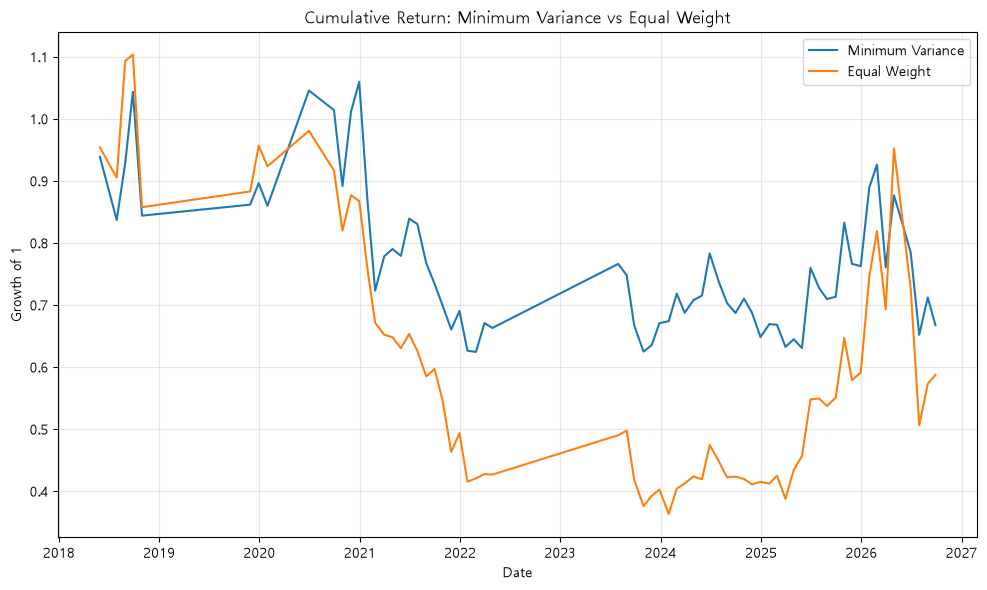

In [135]:
# ============================================================
# 누적수익률 그래프
# ============================================================

mvo_cum = (1 + mvo_ret).cumprod()
equal_cum = (1 + equal_ret).cumprod()

plt.figure(figsize=(10, 6))

plt.plot(
    mvo_cum.index,
    mvo_cum,
    label="Minimum Variance"
)

plt.plot(
    equal_cum.index,
    equal_cum,
    label="Equal Weight"
)

plt.xlabel("Date")
plt.ylabel("Growth of 1")
plt.title("Cumulative Return: Minimum Variance vs Equal Weight")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "final_cumulative_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

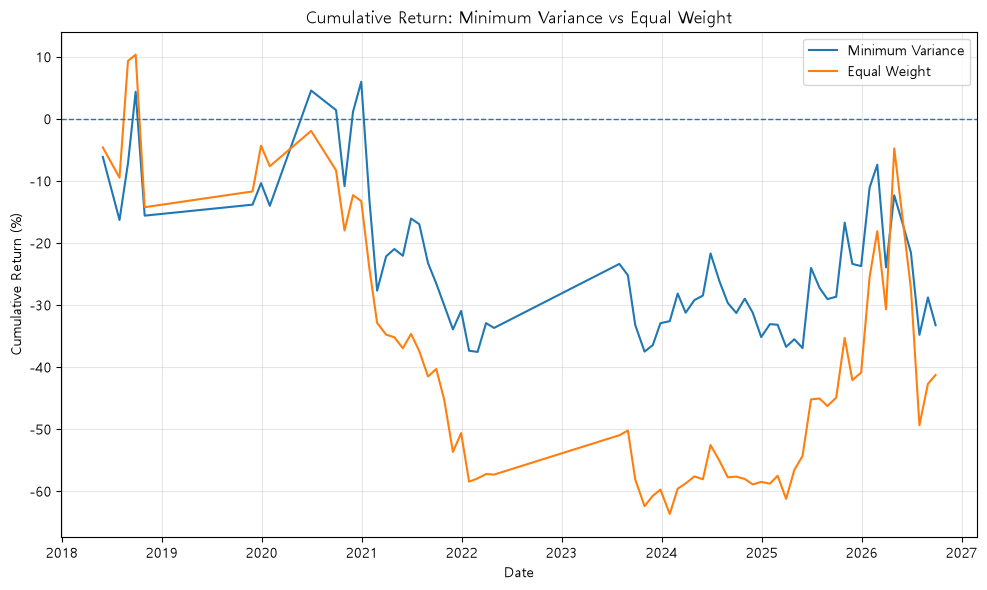

In [136]:
# 누적수익률(%) 계산
mvo_cum_return = ((1 + mvo_ret).cumprod() - 1) * 100
equal_cum_return = ((1 + equal_ret).cumprod() - 1) * 100

plt.figure(figsize=(10, 6))

plt.plot(
    mvo_cum_return.index,
    mvo_cum_return,
    label="Minimum Variance"
)

plt.plot(
    equal_cum_return.index,
    equal_cum_return,
    label="Equal Weight"
)

# 0% 기준선
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.title("Cumulative Return: Minimum Variance vs Equal Weight")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "final_cumulative_return_percent.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [137]:
((1 + mvo_ret).cumprod() - 1) * 100

date
2018-05-31    -6.147217
2018-07-31   -16.317175
2018-08-31    -7.158231
2018-09-28     4.343512
2018-10-31   -15.619948
                ...    
2026-05-29   -16.655210
2026-06-30   -21.592574
2026-07-31   -34.824796
2026-08-31   -28.798048
2026-09-28   -33.274431
Name: return, Length: 68, dtype: float64

# 실전 운용용 패치 (2026-10-01)

기존 탐색용/발표용 셀은 그대로 두고, 아래 셀부터 실전 주문 후보와 목표비중을 생성합니다.

수정 내용은 ① 공식 투자가능 506종목과 교집합, ② 섹터·종목 모멘텀을 1/3/6/12M **순위점수 평균**으로 변경, ③ 현재 섹터 한도 적용, ④ 개별종목 내부 상한 15%, ⑤ 시총 1조 미만 합계 30% 입니다.

먼저 기존 데이터 정리 셀을 실행하여 `price`, `mcap`, `sector_etf`, `sector_etf_map` 변수가 존재해야 합니다.


In [ ]:
# A. 공식 투자가능종목 + 현재 섹터 한도
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.optimize import minimize, linprog

OFFICIAL_UNIVERSE_FILE = "모의투자_투자가능종목(1).xlsx"
SECTOR_LIMIT_FILE = "섹터 비중(2).xlsx"

_official = pd.read_excel(
    OFFICIAL_UNIVERSE_FILE,
    sheet_name="Sector",
    usecols="F:J",
    skiprows=2
)
_official.columns = ["섹터코드", "섹터명", "종목코드", "종목명", "시장"]
_official = _official.dropna(subset=["종목코드"]).copy()
_official["종목코드"] = (
    _official["종목코드"].astype(str)
    .str.replace("A", "", regex=False)
    .str.replace(".0", "", regex=False)
    .str.zfill(6)
)
OFFICIAL_CODES = set(_official["종목코드"])

_sector_limit_df = pd.read_excel(SECTOR_LIMIT_FILE, sheet_name="섹터 비중")
_sector_limit_df["한도 비중"] = pd.to_numeric(_sector_limit_df["한도 비중"], errors="coerce")
SECTOR_LIMITS = (
    _sector_limit_df.dropna(subset=["섹터명", "한도 비중"])
    .set_index("섹터명")["한도 비중"]
    .clip(upper=100)
    .div(100)
    .to_dict()
)

print("공식 투자가능 종목 수:", len(OFFICIAL_CODES))
print("섹터 한도:", {k: round(v*100, 2) for k, v in SECTOR_LIMITS.items()})


In [ ]:
# B. 순위 기반 섹터 모멘텀 + 공식 투자가능종목 교집합

def get_strategy_universe_live(date):
    date = pd.Timestamp(date)
    loc = sector_etf.index.get_loc(date)
    horizons = {"1M": 21, "3M": 63, "6M": 126, "12M": 252}

    etf_rows = {}
    for etf in sector_etf.columns:
        cur = sector_etf.loc[date, etf]
        row = {}
        for h, lag in horizons.items():
            if loc < lag:
                row[h] = np.nan
                continue
            past = sector_etf.iloc[loc-lag][etf]
            row[h] = cur/past - 1 if pd.notna(cur) and pd.notna(past) and past != 0 else np.nan
        etf_rows[etf] = row
    etf_mom = pd.DataFrame(etf_rows).T

    sector_result = {}
    for sector, etfs in sector_etf_map.items():
        sector_result[sector] = etf_mom.loc[etfs, list(horizons)].mean(axis=0)
    sector_result = pd.DataFrame(sector_result).T

    score_cols = []
    for h in horizons:
        c = f"{h}_RankScore"
        sector_result[c] = sector_result[h].rank(ascending=True, pct=True, method="average")
        score_cols.append(c)
    sector_result["CompositeRank"] = sector_result[score_cols].mean(axis=1)

    median_score = sector_result["CompositeRank"].median()
    sector_result["Positive_12M"] = sector_result["12M"] > 0
    sector_result["Above_Median"] = sector_result["CompositeRank"] >= median_score
    sector_result["Selected"] = sector_result["Positive_12M"] & sector_result["Above_Median"]
    selected_sectors = sector_result.index[sector_result["Selected"]].tolist()

    universe = _official[_official["섹터명"].isin(selected_sectors)].copy()
    valid_price_codes = set(price.loc[date].dropna().index)
    universe = universe[universe["종목코드"].isin(valid_price_codes)].copy()

    return {
        "sector_result": sector_result.sort_values("CompositeRank", ascending=False),
        "selected_sectors": selected_sectors,
        "universe": universe
    }


In [ ]:
# C. PCA 75% + Ward 8군집 + 군집별 모멘텀 상위 3개
LIVE_LOOKBACK = 252
LIVE_K = 8
LIVE_TOP_PER_CLUSTER = 3


def calc_stock_rank_momentum(date, codes):
    date = pd.Timestamp(date)
    loc = price.index.get_loc(date)
    horizons = {"1M": 21, "3M": 63, "6M": 126, "12M": 252}
    rows = []

    for code in codes:
        cur = price.loc[date, code]
        row = {"종목코드": code}
        ok = True
        for h, lag in horizons.items():
            if loc < lag:
                ok = False
                break
            past = price.iloc[loc-lag][code]
            if pd.isna(cur) or pd.isna(past) or past == 0:
                ok = False
                break
            row[h] = cur/past - 1
        if ok:
            rows.append(row)

    mom = pd.DataFrame(rows)
    if mom.empty:
        return mom

    score_cols = []
    for h in horizons:
        c = f"{h}_RankScore"
        mom[c] = mom[h].rank(ascending=True, pct=True, method="average")
        score_cols.append(c)
    mom["CompositeRank"] = mom[score_cols].mean(axis=1)
    return mom


def build_live_candidates(date):
    date = pd.Timestamp(date)
    strategy = get_strategy_universe_live(date)
    codes = strategy["universe"]["종목코드"].tolist()
    loc = price.index.get_loc(date)

    px = price.iloc[loc-LIVE_LOOKBACK:loc+1][codes]
    ret = px.pct_change(fill_method=None)
    missing = ret.isna().mean()
    valid_codes = missing[missing <= 0.20].index.tolist()

    ret = ret[valid_codes]
    ret_filled = ret.apply(lambda x: x.fillna(x.mean()), axis=0)
    X = StandardScaler().fit_transform(ret_filled)

    pca = PCA(n_components=0.75, svd_solver="full")
    pca.fit(X)
    loading = pd.DataFrame(pca.components_.T, index=valid_codes)

    model = AgglomerativeClustering(n_clusters=LIVE_K, linkage="ward")
    labels = model.fit_predict(loading.values)
    cluster_df = pd.DataFrame({"종목코드": valid_codes, "cluster": labels})

    mom = calc_stock_rank_momentum(date, valid_codes)
    ranked = cluster_df.merge(mom, on="종목코드", how="left").dropna(subset=["CompositeRank"])
    candidates = (
        ranked.sort_values(["cluster", "CompositeRank"], ascending=[True, False])
        .groupby("cluster")
        .head(LIVE_TOP_PER_CLUSTER)
        .copy()
    )

    candidates = candidates.merge(
        _official[["종목코드", "종목명", "섹터명", "시장"]],
        on="종목코드",
        how="left"
    )
    candidates["시가총액_백만원"] = candidates["종목코드"].map(mcap.loc[date])
    candidates = candidates.dropna(subset=["시가총액_백만원", "섹터명"])
    return strategy, candidates, pca.explained_variance_ratio_.sum()


In [ ]:
# D. 실전 Minimum Variance — 규정 제약 반영
LIVE_MAX_STOCK = 0.15
LIVE_SMALL_CAP_LIMIT = 0.30
LIVE_SMALL_CAP_THRESHOLD = 1_000_000  # 백만원 = 1조원


def optimize_live_weights(date, candidates):
    date = pd.Timestamp(date)
    codes = candidates["종목코드"].tolist()
    loc = price.index.get_loc(date)

    ret = (
        price.iloc[loc-LIVE_LOOKBACK:loc+1][codes]
        .pct_change(fill_method=None)
        .apply(lambda x: x.fillna(x.mean()), axis=0)
    )
    cov = ret.cov().values * 252
    n = len(codes)

    meta = candidates.set_index("종목코드").loc[codes]
    sectors = meta["섹터명"].values
    mcaps = meta["시가총액_백만원"].values
    small = mcaps < LIVE_SMALL_CAP_THRESHOLD
    bounds = [(0, LIVE_MAX_STOCK) for _ in range(n)]

    A_ub, b_ub = [], []
    row = np.zeros(n); row[small] = 1
    A_ub.append(row); b_ub.append(LIVE_SMALL_CAP_LIMIT)

    for sector in np.unique(sectors):
        limit = SECTOR_LIMITS.get(sector, 0.10)
        row = np.zeros(n); row[sectors == sector] = 1
        A_ub.append(row); b_ub.append(limit)

    lp = linprog(
        c=np.zeros(n), A_ub=np.array(A_ub), b_ub=np.array(b_ub),
        A_eq=np.ones((1, n)), b_eq=np.array([1.0]),
        bounds=bounds, method="highs"
    )
    if not lp.success:
        raise ValueError("현재 후보군으로 규정 제약을 동시에 만족시킬 수 없습니다.")

    def variance(w):
        return w @ cov @ w

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w)-1}]
    constraints.append({"type": "ineq", "fun": lambda w: LIVE_SMALL_CAP_LIMIT-np.sum(w[small])})
    for sector in np.unique(sectors):
        mask = sectors == sector
        limit = SECTOR_LIMITS.get(sector, 0.10)
        constraints.append({
            "type": "ineq",
            "fun": lambda w, m=mask, lim=limit: lim-np.sum(w[m])
        })

    res = minimize(
        variance, x0=lp.x, method="SLSQP",
        bounds=bounds, constraints=constraints,
        options={"maxiter": 2000, "ftol": 1e-12}
    )
    if not res.success:
        raise ValueError("MVO 실패: " + res.message)
    return pd.Series(res.x, index=codes)


SIGNAL_DATE = price.index.max()
live_strategy, live_candidates, explained = build_live_candidates(SIGNAL_DATE)
live_weights = optimize_live_weights(SIGNAL_DATE, live_candidates)

order_table = live_candidates[[
    "종목코드", "종목명", "섹터명", "시장", "cluster",
    "CompositeRank", "시가총액_백만원"
]].copy()
order_table["목표비중"] = order_table["종목코드"].map(live_weights).fillna(0)
order_table["목표비중(%)"] = (order_table["목표비중"]*100).round(2)
order_table = order_table.sort_values("목표비중", ascending=False).reset_index(drop=True)
trade_table = order_table[order_table["목표비중"] >= 0.001].copy()

print("기준일:", SIGNAL_DATE.date())
print("선택 섹터:", live_strategy["selected_sectors"])
print("공식 투자가능 교집합:", len(live_strategy["universe"]))
print("PCA 누적설명률:", round(explained, 4))
print("후보 수:", len(live_candidates))
print()
print(trade_table[[
    "종목코드", "종목명", "섹터명", "cluster",
    "CompositeRank", "시가총액_백만원", "목표비중(%)"
]].to_string(index=False))

print("비중 합:", round(trade_table["목표비중"].sum(), 6))
print("최대 개별 비중:", round(trade_table["목표비중"].max()*100, 2), "%")
small_w = trade_table.loc[
    trade_table["시가총액_백만원"] < LIVE_SMALL_CAP_THRESHOLD,
    "목표비중"
].sum()
print("시총 1조 미만 합계:", round(small_w*100, 2), "%")
for sector, grp in trade_table.groupby("섹터명"):
    w = grp["목표비중"].sum()
    lim = SECTOR_LIMITS.get(sector, 0.10)
    print(f"{sector}: {w*100:.2f}% / 한도 {lim*100:.2f}%")

trade_table.to_excel(f"실전_목표비중_{SIGNAL_DATE.strftime('%Y%m%d')}.xlsx", index=False)


## 중요
기존 백테스트는 월말 리밸런싱이므로 그대로 주문 판단에 쓰지 마세요. 다음 단계에서는 **목요일 주 1회 리밸런싱**, 가격변동 후 실제 보유비중 기준 회전율, 주간 회전율 5% 확인, 거래비용 가정을 반영한 백테스트로 바꿔야 합니다.


# E. 주간 백테스트 v2 — 실패 주도 끊기지 않는 연속 운용

이 버전은 이전 테스트에서 확인된 세 가지 문제를 수정합니다.

1. **후보 부족 시 자동 확대**: 군집별 Top 3부터 시작해 Top 4, 5, 6, 8, 10, 12, 필요 시 군집 전체까지 후보를 넓힙니다.
2. **섹터 부족 시 자동 보충**: 원래 조건(12M > 0 + CompositeRank 중간 이상)을 우선 적용하고, 규정상 포트폴리오를 만들 수 없을 때만 12M > 0인 다음 순위 섹터를 하나씩 추가합니다.
3. **신호 생성 실패 주도 계좌를 유지**: 해당 주를 삭제하지 않고 기존 포트폴리오를 그대로 보유하며 수익률을 계산합니다. 이때 회전율은 0%입니다.

따라서 최종 성과곡선은 성공한 주만 이어 붙이는 것이 아니라 **매주 연속된 실제 계좌 흐름**에 가깝게 계산됩니다.


In [ ]:
# ============================================================
# E. 주간 백테스트 v2 — 연속 운용 / 후보 자동 확대 / 섹터 자동 보충
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.optimize import minimize, linprog

# ------------------------------------------------------------
# 0. 설정
# ------------------------------------------------------------
BT_LOOKBACK = 252
BT_K = 8
BT_INITIAL_TOP_PER_CLUSTER = 3

BT_MAX_STOCK = 0.15
BT_SMALL_CAP_LIMIT = 0.30
BT_SMALL_CAP_THRESHOLD = 1_000_000  # 백만원 = 1조원

BUY_COST = 0.001   # 매수 0.1%
SELL_COST = 0.003  # 매도 0.3%

MIN_WEEKLY_TURNOVER = 0.05

# 먼저 2022~현재로 정상 동작을 확인합니다.
# 정상 확인 후 2018-04-01로 바꾸어 전체기간을 돌리면 됩니다.
BT_START = pd.Timestamp("2022-01-01")
BT_END = price.index.max()


# ------------------------------------------------------------
# 1. 날짜별 섹터 한도
#    시장비중 2배, 시장비중 5% 이하이면 10%
# ------------------------------------------------------------
def get_historical_sector_limits(date):
    date = pd.Timestamp(date)

    tmp = sector_map[["종목코드", "섹터명"]].drop_duplicates().copy()
    tmp["시가총액"] = tmp["종목코드"].map(mcap.loc[date])
    tmp = tmp.dropna(subset=["섹터명", "시가총액"])
    tmp = tmp[tmp["시가총액"] > 0]

    sector_mcap = tmp.groupby("섹터명")["시가총액"].sum()

    if sector_mcap.sum() <= 0:
        raise ValueError("섹터 시가총액 합계를 계산할 수 없습니다.")

    market_weight = sector_mcap / sector_mcap.sum()

    limits = {}
    for sector, w in market_weight.items():
        limits[sector] = 0.10 if w <= 0.05 else min(1.0, 2.0 * w)

    return limits


# ------------------------------------------------------------
# 2. 날짜별 섹터 모멘텀 계산
#    기본선정 = 12M > 0 & CompositeRank 중앙값 이상
# ------------------------------------------------------------
def get_sector_momentum_bt(date):
    date = pd.Timestamp(date)

    if date not in sector_etf.index:
        raise ValueError(f"{date.date()}가 sector_etf에 없습니다.")

    loc = sector_etf.index.get_loc(date)
    horizons = {"1M": 21, "3M": 63, "6M": 126, "12M": 252}

    etf_rows = {}

    for etf in sector_etf.columns:
        cur = sector_etf.loc[date, etf]
        row = {}

        for h, lag in horizons.items():
            if loc < lag:
                row[h] = np.nan
                continue

            past = sector_etf.iloc[loc - lag][etf]
            row[h] = (
                cur / past - 1
                if pd.notna(cur) and pd.notna(past) and past != 0
                else np.nan
            )

        etf_rows[etf] = row

    etf_mom = pd.DataFrame(etf_rows).T

    sector_rows = {}

    for sector, etfs in sector_etf_map.items():
        usable = [e for e in etfs if e in etf_mom.index]

        if not usable:
            continue

        sector_rows[sector] = etf_mom.loc[usable, list(horizons)].mean(axis=0)

    sector_result = pd.DataFrame(sector_rows).T

    if sector_result.empty:
        raise ValueError("섹터 모멘텀을 계산할 수 없습니다.")

    score_cols = []

    for h in horizons:
        c = f"{h}_RankScore"
        sector_result[c] = sector_result[h].rank(
            ascending=True,
            pct=True,
            method="average"
        )
        score_cols.append(c)

    sector_result["CompositeRank"] = sector_result[score_cols].mean(axis=1)
    median_score = sector_result["CompositeRank"].median()

    sector_result["Positive_12M"] = sector_result["12M"] > 0
    sector_result["Above_Median"] = sector_result["CompositeRank"] >= median_score
    sector_result["Selected_Base"] = (
        sector_result["Positive_12M"]
        & sector_result["Above_Median"]
    )

    base_selected = (
        sector_result.index[sector_result["Selected_Base"]]
        .tolist()
    )

    positive_order = (
        sector_result[sector_result["Positive_12M"]]
        .sort_values("CompositeRank", ascending=False)
        .index
        .tolist()
    )

    return sector_result.sort_values("CompositeRank", ascending=False), base_selected, positive_order


# ------------------------------------------------------------
# 3. 선택 섹터로 해당 날짜의 역사적 유니버스 구성
# ------------------------------------------------------------
def make_strategy_universe_bt(date, selected_sectors):
    date = pd.Timestamp(date)

    base_codes = get_universe(date)

    universe = (
        pd.DataFrame({"종목코드": sorted(base_codes)})
        .merge(
            sector_map[["종목코드", "종목명", "섹터명"]]
            .drop_duplicates("종목코드"),
            on="종목코드",
            how="left"
        )
    )

    universe = universe[
        universe["섹터명"].isin(selected_sectors)
    ].copy()

    valid_price_codes = set(price.loc[date].dropna().index)
    universe = universe[
        universe["종목코드"].isin(valid_price_codes)
    ].copy()

    return universe


# ------------------------------------------------------------
# 4. 종목 모멘텀: 1/3/6/12M 상대순위 평균
# ------------------------------------------------------------
def calc_stock_rank_momentum_bt(date, codes):
    date = pd.Timestamp(date)
    loc = price.index.get_loc(date)
    horizons = {"1M": 21, "3M": 63, "6M": 126, "12M": 252}

    rows = []

    for code in codes:
        cur = price.loc[date, code]
        row = {"종목코드": code}
        ok = True

        for h, lag in horizons.items():
            if loc < lag:
                ok = False
                break

            past = price.iloc[loc - lag][code]

            if pd.isna(cur) or pd.isna(past) or past == 0:
                ok = False
                break

            row[h] = cur / past - 1

        if ok:
            rows.append(row)

    mom = pd.DataFrame(rows)

    if mom.empty:
        return mom

    score_cols = []

    for h in horizons:
        c = f"{h}_RankScore"
        mom[c] = mom[h].rank(
            ascending=True,
            pct=True,
            method="average"
        )
        score_cols.append(c)

    mom["CompositeRank"] = mom[score_cols].mean(axis=1)

    return mom


# ------------------------------------------------------------
# 5. PCA + 군집 전체 랭킹 생성
#    여기서는 아직 Top N을 자르지 않습니다.
# ------------------------------------------------------------
def build_cluster_ranked_universe_bt(date, universe):
    date = pd.Timestamp(date)
    codes = universe["종목코드"].tolist()

    if len(codes) < 10:
        raise ValueError("전략 유니버스 종목 수가 너무 적습니다.")

    loc = price.index.get_loc(date)

    if loc < BT_LOOKBACK:
        raise ValueError("PCA lookback 데이터가 부족합니다.")

    px = price.iloc[loc - BT_LOOKBACK : loc + 1][codes].copy()
    ret = px.pct_change(fill_method=None)

    missing = ret.isna().mean()
    valid_codes = missing[missing <= 0.20].index.tolist()

    if len(valid_codes) < 10:
        raise ValueError("PCA 가능 종목 수가 너무 적습니다.")

    ret = ret[valid_codes].copy()

    # 평균조차 계산되지 않는 완전 결측 종목 제거
    valid_codes = ret.columns[ret.mean().notna()].tolist()
    ret = ret[valid_codes]

    if len(valid_codes) < 10:
        raise ValueError("결측 제거 후 PCA 가능 종목 수가 너무 적습니다.")

    ret_filled = ret.apply(lambda x: x.fillna(x.mean()), axis=0)

    X = StandardScaler().fit_transform(ret_filled)

    pca = PCA(n_components=0.75, svd_solver="full")
    pca.fit(X)

    loading = pd.DataFrame(
        pca.components_.T,
        index=valid_codes
    )

    k = min(BT_K, len(valid_codes) - 1)

    if k < 2:
        raise ValueError("군집 수를 만들 수 없습니다.")

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(loading.values)

    cluster_df = pd.DataFrame({
        "종목코드": valid_codes,
        "cluster": labels
    })

    mom = calc_stock_rank_momentum_bt(date, valid_codes)

    ranked = (
        cluster_df
        .merge(mom, on="종목코드", how="left")
        .dropna(subset=["CompositeRank"])
        .merge(
            sector_map[["종목코드", "종목명", "섹터명"]]
            .drop_duplicates("종목코드"),
            on="종목코드",
            how="left"
        )
    )

    ranked["시가총액_백만원"] = ranked["종목코드"].map(mcap.loc[date])
    ranked = ranked.dropna(subset=["섹터명", "시가총액_백만원"])

    ranked = ranked.sort_values(
        ["cluster", "CompositeRank"],
        ascending=[True, False]
    ).reset_index(drop=True)

    explained = float(pca.explained_variance_ratio_.sum())

    return ranked, explained


# ------------------------------------------------------------
# 6. 규정 제약 데이터 + feasibility LP
# ------------------------------------------------------------
def prepare_constraints_bt(date, candidates):
    date = pd.Timestamp(date)

    candidates = candidates.drop_duplicates("종목코드").copy()
    codes = candidates["종목코드"].tolist()
    n = len(codes)

    if n == 0:
        raise ValueError("후보 종목이 없습니다.")

    meta = candidates.set_index("종목코드").loc[codes]
    sectors = meta["섹터명"].values
    mcaps = meta["시가총액_백만원"].values.astype(float)
    small = mcaps < BT_SMALL_CAP_THRESHOLD

    sector_limits = get_historical_sector_limits(date)
    bounds = [(0, BT_MAX_STOCK) for _ in range(n)]

    A_ub = []
    b_ub = []

    # 시총 1조 미만 합계 <= 30%
    row = np.zeros(n)
    row[small] = 1.0
    A_ub.append(row)
    b_ub.append(BT_SMALL_CAP_LIMIT)

    # 섹터별 한도
    for sector in np.unique(sectors):
        limit = sector_limits.get(sector, 0.10)
        row = np.zeros(n)
        row[sectors == sector] = 1.0
        A_ub.append(row)
        b_ub.append(limit)

    lp = linprog(
        c=np.zeros(n),
        A_ub=np.array(A_ub),
        b_ub=np.array(b_ub),
        A_eq=np.ones((1, n)),
        b_eq=np.array([1.0]),
        bounds=bounds,
        method="highs"
    )

    if not lp.success:
        raise ValueError("현재 후보군으로 규정 제약을 동시에 만족시킬 수 없습니다.")

    constraints = [
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1.0
        },
        {
            "type": "ineq",
            "fun": lambda w, s=small: BT_SMALL_CAP_LIMIT - np.sum(w[s])
        }
    ]

    for sector in np.unique(sectors):
        mask = sectors == sector
        limit = sector_limits.get(sector, 0.10)

        constraints.append({
            "type": "ineq",
            "fun": lambda w, m=mask, lim=limit: lim - np.sum(w[m])
        })

    return {
        "candidates": candidates,
        "codes": codes,
        "sectors": sectors,
        "mcaps": mcaps,
        "small": small,
        "sector_limits": sector_limits,
        "bounds": bounds,
        "constraints": constraints,
        "x0": lp.x
    }


# ------------------------------------------------------------
# 7. 후보군 자동 확대 + 섹터 자동 보충
# ------------------------------------------------------------
def build_feasible_candidates_bt(date):
    date = pd.Timestamp(date)

    sector_result, base_selected, positive_order = get_sector_momentum_bt(date)

    if len(positive_order) == 0:
        raise ValueError("12개월 절대수익률이 양수인 섹터가 없습니다.")

    # 기본 선정 섹터를 먼저 쓰고, 부족할 때만 양(+)의 다음 순위 섹터 추가
    selected = list(base_selected)
    add_order = [s for s in positive_order if s not in selected]

    # base가 비어 있어도 보충 규칙이 작동하도록 0개 추가부터 전부 추가까지 탐색
    sector_attempts = []

    for n_add in range(len(add_order) + 1):
        active_sectors = selected + add_order[:n_add]

        if len(active_sectors) == 0:
            continue

        universe = make_strategy_universe_bt(date, active_sectors)

        if len(universe) < 10:
            sector_attempts.append(
                f"{len(active_sectors)}개 섹터/유니버스 {len(universe)}개"
            )
            continue

        try:
            ranked, explained = build_cluster_ranked_universe_bt(date, universe)
        except Exception as e:
            sector_attempts.append(
                f"{len(active_sectors)}개 섹터/PCA 실패: {e}"
            )
            continue

        if ranked.empty:
            sector_attempts.append(
                f"{len(active_sectors)}개 섹터/랭킹 0개"
            )
            continue

        max_cluster_size = int(ranked.groupby("cluster").size().max())

        # 필요 이상으로 크게 늘리지 않되, 마지막에는 군집 전체까지 허용
        raw_top_seq = [
            BT_INITIAL_TOP_PER_CLUSTER,
            4, 5, 6, 8, 10, 12,
            max_cluster_size
        ]

        top_seq = []
        for t in raw_top_seq:
            t = int(max(1, min(t, max_cluster_size)))
            if t not in top_seq:
                top_seq.append(t)

        for top_n in top_seq:
            candidates = (
                ranked
                .groupby("cluster", group_keys=False)
                .head(top_n)
                .copy()
            )

            try:
                prepare_constraints_bt(date, candidates)

                added = [s for s in active_sectors if s not in base_selected]

                return {
                    "sector_result": sector_result,
                    "base_selected": base_selected,
                    "selected_sectors": active_sectors,
                    "added_sectors": added,
                    "universe": universe,
                    "ranked": ranked,
                    "candidates": candidates,
                    "pca_explained": explained,
                    "top_per_cluster_used": top_n
                }

            except ValueError:
                pass

        sector_attempts.append(
            f"{len(active_sectors)}개 섹터/최대 후보 {len(ranked)}개도 제약 불가"
        )

    detail = " | ".join(sector_attempts[-4:])
    raise ValueError(
        "양(+) 모멘텀 섹터와 후보 자동 확대를 모두 적용했지만 "
        "규정 제약을 만족하는 후보군을 만들지 못했습니다."
        + (f" ({detail})" if detail else "")
    )


# ------------------------------------------------------------
# 8. MVO / Equal-like Weight
# ------------------------------------------------------------
def optimize_mvo_bt(date, candidates):
    date = pd.Timestamp(date)
    prep = prepare_constraints_bt(date, candidates)

    codes = prep["codes"]
    loc = price.index.get_loc(date)

    ret = (
        price.iloc[loc - BT_LOOKBACK : loc + 1][codes]
        .pct_change(fill_method=None)
        .apply(lambda x: x.fillna(x.mean()), axis=0)
    )

    cov = ret.cov().values * 252

    # 수치 안정성 보강
    cov = cov + np.eye(len(codes)) * 1e-10

    def variance(w):
        return float(w @ cov @ w)

    res = minimize(
        variance,
        x0=prep["x0"],
        method="SLSQP",
        bounds=prep["bounds"],
        constraints=prep["constraints"],
        options={"maxiter": 1500, "ftol": 1e-11, "disp": False}
    )

    if not res.success:
        raise ValueError("MVO 실패: " + res.message)

    w = pd.Series(res.x, index=codes)
    w[w < 1e-8] = 0.0
    w = w / w.sum()
    return w


def optimize_equal_bt(date, candidates):
    prep = prepare_constraints_bt(date, candidates)

    codes = prep["codes"]
    n = len(codes)
    target = np.repeat(1.0 / n, n)

    def distance_to_equal(w):
        return float(np.sum((w - target) ** 2))

    res = minimize(
        distance_to_equal,
        x0=prep["x0"],
        method="SLSQP",
        bounds=prep["bounds"],
        constraints=prep["constraints"],
        options={"maxiter": 1500, "ftol": 1e-12, "disp": False}
    )

    if not res.success:
        raise ValueError("Equal-like 최적화 실패: " + res.message)

    w = pd.Series(res.x, index=codes)
    w[w < 1e-8] = 0.0
    w = w / w.sum()
    return w


# ------------------------------------------------------------
# 9. 주간 신호일 생성
#    W-THU = 목요일까지 한 주. 휴장이면 그 주의 직전 마지막 거래일
# ------------------------------------------------------------
common_dates = price.index.intersection(sector_etf.index).sort_values()
common_dates = common_dates[
    (common_dates >= BT_START)
    & (common_dates <= BT_END)
]

weekly_signal_dates = (
    pd.Series(common_dates, index=common_dates)
    .groupby(common_dates.to_period("W-THU"))
    .last()
    .tolist()
)

weekly_signal_dates = [
    d for d in weekly_signal_dates
    if price.index.get_loc(d) >= BT_LOOKBACK
    and sector_etf.index.get_loc(d) >= BT_LOOKBACK
]

if len(weekly_signal_dates) < 2:
    raise ValueError("백테스트 가능한 주간 신호일이 부족합니다.")

print("백테스트 신호 주 수:", len(weekly_signal_dates))
print("기간:", weekly_signal_dates[0].date(), "~", weekly_signal_dates[-1].date())


# ------------------------------------------------------------
# 10. 다음 거래일
# ------------------------------------------------------------
def next_trading_day(date):
    pos = price.index.searchsorted(pd.Timestamp(date), side="right")

    if pos >= len(price.index):
        return None

    return price.index[pos]


# ------------------------------------------------------------
# 11. 리밸런싱 통계 / 보유기간 수익률
# ------------------------------------------------------------
def rebalance_stats(current_weights, target_weights):
    all_codes = current_weights.index.union(target_weights.index)

    old = current_weights.reindex(all_codes, fill_value=0.0)
    new = target_weights.reindex(all_codes, fill_value=0.0)

    delta = new - old
    buys = float(delta[delta > 0].sum())
    sells = float(-delta[delta < 0].sum())

    turnover = 0.5 * (buys + sells)
    cost = BUY_COST * buys + SELL_COST * sells

    return {
        "buy": buys,
        "sell": sells,
        "turnover": turnover,
        "cost": cost
    }


def asset_period_returns(start_date, end_date, codes):
    if len(codes) == 0:
        return pd.Series(dtype=float)

    p0 = price.loc[start_date, codes].astype(float)
    p1 = price.loc[end_date, codes].astype(float)

    r = p1 / p0 - 1.0

    # 정지/결측은 0%로 처리. 최종 해석 시 백테스트 한계로 명시합니다.
    return r.replace([np.inf, -np.inf], np.nan).fillna(0.0)


def run_one_period(current_weights, target_weights, exec_date, next_exec_date):
    stats = rebalance_stats(current_weights, target_weights)
    codes = target_weights.index.tolist()

    if len(codes) == 0:
        return {
            "gross_return": 0.0,
            "net_return": 0.0,
            "turnover": stats["turnover"],
            "cost": stats["cost"],
            "buy": stats["buy"],
            "sell": stats["sell"],
            "end_weights": target_weights.copy()
        }

    asset_ret = asset_period_returns(exec_date, next_exec_date, codes)

    gross_port_ret = float(
        (target_weights * asset_ret.reindex(target_weights.index)).sum()
    )

    net_port_ret = (1.0 - stats["cost"]) * (1.0 + gross_port_ret) - 1.0

    gross_values = target_weights * (
        1.0 + asset_ret.reindex(target_weights.index)
    )

    total = gross_values.sum()
    end_weights = (
        gross_values / total
        if total > 0
        else target_weights.copy()
    )

    return {
        "gross_return": gross_port_ret,
        "net_return": net_port_ret,
        "turnover": stats["turnover"],
        "cost": stats["cost"],
        "buy": stats["buy"],
        "sell": stats["sell"],
        "end_weights": end_weights
    }


# ------------------------------------------------------------
# 12. 전체 주간 백테스트
#    신호 실패 시 기존 포트폴리오 그대로 HOLD
# ------------------------------------------------------------
mvo_current = pd.Series(dtype=float)
eq_current = pd.Series(dtype=float)

mvo_started = False
eq_started = False

mvo_rows = []
eq_rows = []
signal_rows = []
fail_rows = []

expected_periods = 0

for i in range(len(weekly_signal_dates) - 1):
    signal_date = weekly_signal_dates[i]
    next_signal = weekly_signal_dates[i + 1]

    exec_date = next_trading_day(signal_date)
    next_exec = next_trading_day(next_signal)

    if exec_date is None or next_exec is None or next_exec <= exec_date:
        continue

    expected_periods += 1

    status = "REBALANCE"
    fail_reason = ""
    strategy_info = None
    mvo_target = None
    eq_target = None

    try:
        strategy_info = build_feasible_candidates_bt(signal_date)
        candidates = strategy_info["candidates"]

        # 두 전략 모두 생성될 때만 이번 주 리밸런싱
        mvo_target = optimize_mvo_bt(signal_date, candidates)
        eq_target = optimize_equal_bt(signal_date, candidates)

    except Exception as e:
        status = "HOLD"
        fail_reason = str(e)

        # 실패 주를 삭제하지 않고 기존 보유비중 유지
        mvo_target = mvo_current.copy()
        eq_target = eq_current.copy()

        fail_rows.append({
            "signal_date": signal_date,
            "status": status,
            "error": fail_reason
        })

    # 첫 진입 여부 기록
    mvo_initial_entry = (not mvo_started) and len(mvo_target) > 0
    eq_initial_entry = (not eq_started) and len(eq_target) > 0

    mvo_result = run_one_period(
        mvo_current,
        mvo_target,
        exec_date,
        next_exec
    )

    eq_result = run_one_period(
        eq_current,
        eq_target,
        exec_date,
        next_exec
    )

    if len(mvo_target) > 0:
        mvo_started = True
    if len(eq_target) > 0:
        eq_started = True

    mvo_current = mvo_result["end_weights"]
    eq_current = eq_result["end_weights"]

    common_row = {
        "signal_date": signal_date,
        "exec_date": exec_date,
        "next_exec_date": next_exec,
        "status": status,
        "fail_reason": fail_reason
    }

    mvo_rows.append({
        **common_row,
        "return": mvo_result["net_return"],
        "gross_return": mvo_result["gross_return"],
        "turnover": mvo_result["turnover"],
        "cost": mvo_result["cost"],
        "buy": mvo_result["buy"],
        "sell": mvo_result["sell"],
        "active": mvo_started,
        "initial_entry": mvo_initial_entry,
        "n_positions": int((mvo_target > 0.001).sum()) if len(mvo_target) else 0
    })

    eq_rows.append({
        **common_row,
        "return": eq_result["net_return"],
        "gross_return": eq_result["gross_return"],
        "turnover": eq_result["turnover"],
        "cost": eq_result["cost"],
        "buy": eq_result["buy"],
        "sell": eq_result["sell"],
        "active": eq_started,
        "initial_entry": eq_initial_entry,
        "n_positions": int((eq_target > 0.001).sum()) if len(eq_target) else 0
    })

    if strategy_info is not None:
        signal_rows.append({
            "signal_date": signal_date,
            "status": status,
            "base_selected": ", ".join(strategy_info["base_selected"]),
            "selected_sectors": ", ".join(strategy_info["selected_sectors"]),
            "added_sectors": ", ".join(strategy_info["added_sectors"]),
            "n_universe": len(strategy_info["universe"]),
            "n_candidates": len(strategy_info["candidates"]),
            "top_per_cluster_used": strategy_info["top_per_cluster_used"],
            "pca_explained": strategy_info["pca_explained"],
            "mvo_positions": int((mvo_target > 0.001).sum()),
            "equal_positions": int((eq_target > 0.001).sum())
        })
    else:
        signal_rows.append({
            "signal_date": signal_date,
            "status": status,
            "base_selected": "",
            "selected_sectors": "",
            "added_sectors": "",
            "n_universe": np.nan,
            "n_candidates": np.nan,
            "top_per_cluster_used": np.nan,
            "pca_explained": np.nan,
            "mvo_positions": int((mvo_target > 0.001).sum()) if len(mvo_target) else 0,
            "equal_positions": int((eq_target > 0.001).sum()) if len(eq_target) else 0
        })

    if (i + 1) % 20 == 0 or i == 0:
        print(
            f"{i+1}/{len(weekly_signal_dates)-1}",
            signal_date.date(),
            status
        )


mvo_bt = pd.DataFrame(mvo_rows)
eq_bt = pd.DataFrame(eq_rows)
signal_log = pd.DataFrame(signal_rows)
fail_log = pd.DataFrame(fail_rows)

print("\n========== 연속성 확인 ==========")
print("예상 주간 구간 수:", expected_periods)
print("MVO 기록 구간 수:", len(mvo_bt))
print("Equal 기록 구간 수:", len(eq_bt))
print("리밸런싱 성공 주:", int((signal_log["status"] == "REBALANCE").sum()))
print("기존 포트폴리오 유지(HOLD) 주:", int((signal_log["status"] == "HOLD").sum()))

if len(fail_log) > 0:
    print("\nHOLD 사유 상위:")
    print(fail_log["error"].value_counts().head(10).to_string())


# ------------------------------------------------------------
# 13. 성과 요약
# ------------------------------------------------------------
def weekly_performance_summary(df, strategy_name):
    if df.empty:
        return pd.Series(name=strategy_name, dtype=float)

    r = df["return"].astype(float)
    cumulative_curve = (1.0 + r).cumprod()
    cumulative_return = cumulative_curve.iloc[-1] - 1.0

    years = len(r) / 52.0
    cagr = (
        cumulative_curve.iloc[-1] ** (1.0 / years) - 1.0
        if years > 0 and cumulative_curve.iloc[-1] > 0
        else np.nan
    )

    annual_vol = r.std(ddof=1) * np.sqrt(52)
    sharpe = (
        (r.mean() * 52) / annual_vol
        if annual_vol > 0
        else np.nan
    )

    running_max = cumulative_curve.cummax()
    drawdown = cumulative_curve / running_max - 1.0
    mdd = drawdown.min()

    # 첫 진입 이전 현금대기 주와 최초 진입 주는 회전율 규정 판정에서 제외
    turnover_eval = df[
        (df["active"] == True)
        & (df["initial_entry"] == False)
    ]["turnover"]

    violations = int((turnover_eval < MIN_WEEKLY_TURNOVER).sum())

    return pd.Series({
        "Cumulative Return (%)": cumulative_return * 100,
        "CAGR (%)": cagr * 100,
        "Annualized Volatility (%)": annual_vol * 100,
        "Sharpe Ratio": sharpe,
        "MDD (%)": mdd * 100,
        "Average Turnover (%)": (
            turnover_eval.mean() * 100
            if len(turnover_eval) > 0
            else np.nan
        ),
        "Turnover < 5% Count": violations,
        "HOLD Weeks": int((df["status"] == "HOLD").sum()),
        "Total Trading Cost (%)": df["cost"].sum() * 100,
        "Weeks": len(df)
    }, name=strategy_name)


summary = pd.DataFrame([
    weekly_performance_summary(mvo_bt, "Minimum Variance"),
    weekly_performance_summary(eq_bt, "Equal-like Weight")
])

print("\n========== 최종 성과 비교 ==========")
print(summary.round(2).to_string())

print("\n회전율 5% 미만 허용 횟수를 3회로 본다면:")

for name in summary.index:
    n = int(summary.loc[name, "Turnover < 5% Count"])
    print(
        f"{name}: {n}회 →",
        "3회 초과" if n > 3 else "3회 이내"
    )


# ------------------------------------------------------------
# 14. 누적수익률 그래프 — 모든 주를 연속해서 표시
# ------------------------------------------------------------
if not mvo_bt.empty and not eq_bt.empty:
    mvo_curve = (
        1 + mvo_bt.set_index("next_exec_date")["return"]
    ).cumprod() - 1

    eq_curve = (
        1 + eq_bt.set_index("next_exec_date")["return"]
    ).cumprod() - 1

    plt.figure(figsize=(11, 5))
    plt.plot(
        mvo_curve.index,
        mvo_curve.values * 100,
        label="Minimum Variance"
    )
    plt.plot(
        eq_curve.index,
        eq_curve.values * 100,
        label="Equal-like Weight"
    )
    plt.axhline(0, linewidth=1)
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return (%)")
    plt.title("Weekly Backtest v2: Continuous Portfolio Return")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 15. 결과 저장
# ------------------------------------------------------------
with pd.ExcelWriter("주간백테스트_v2_연속운용_결과.xlsx") as writer:
    summary.to_excel(writer, sheet_name="성과요약")
    mvo_bt.to_excel(writer, sheet_name="MVO_주간", index=False)
    eq_bt.to_excel(writer, sheet_name="Equal_주간", index=False)
    signal_log.to_excel(writer, sheet_name="신호로그", index=False)
    fail_log.to_excel(writer, sheet_name="HOLD로그", index=False)

print("\n저장 완료: 주간백테스트_v2_연속운용_결과.xlsx")


# F. v3 — Turnover-aware 주간 운용

v2에서 확인된 두 문제를 동시에 보완합니다.

1. **HOLD 주 감소**: 기존의 엄격한 섹터/PCA 후보가 실패하면, 상대모멘텀 순위가 높은 섹터와 전체 투자 가능 유니버스를 단계적으로 넓혀 `RESCUE` 후보를 만듭니다.
2. **과도한 매매 억제**: 지난주 실제 보유비중을 최대한 유지하면서 이번 주 목표비중 쪽으로 이동합니다.
3. **주간 회전율 5% 규정**: 최초 진입을 제외하고 목표 회전율 하한을 5.2%로 두어 수치오차 여유를 둡니다.
4. **상한은 유연하게**: 우선 15% 이내 회전율을 시도하고, 제약 충족에 꼭 필요할 때만 25% → 40% → 60% → 100%로 완화합니다.

> `STRICT`가 기본 전략이고 `RESCUE`는 STRICT 후보로 포트폴리오를 만들 수 없을 때만 작동합니다.  
> 먼저 2022~현재 구간으로 검증한 뒤 전체기간으로 확장하세요.


In [ ]:

# ============================================================
# F. v3 — Turnover-aware 주간 운용
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

# ------------------------------------------------------------
# 0. v3 설정
# ------------------------------------------------------------
V3_MIN_TURNOVER = 0.052       # 대회 5% 기준 + 수치오차 여유
V3_PREFERRED_MAX_TURNOVER = 0.15
V3_TURNOVER_CAP_SEQUENCE = [0.15, 0.25, 0.40, 0.60, 1.00]

# 0이면 raw target만 추종, 클수록 기존 보유비중 유지 성향이 강함
V3_KEEP_PENALTY = 6.0

# Rescue 시 섹터별 모멘텀 상위 종목을 단계적으로 확대
V3_RESCUE_PER_SECTOR_SEQ = [5, 10, 15, 25, 40]

# v2와 동일하게 먼저 2022~현재 검증
V3_START = pd.Timestamp("2022-01-01")
V3_END = price.index.max()


# ------------------------------------------------------------
# 1. 현재 보유종목 중 지금도 투자 가능한 종목을 후보 pool에 보존
# ------------------------------------------------------------
def v3_add_valid_current_holdings(date, candidates, current_weights):
    date = pd.Timestamp(date)

    base = candidates.drop_duplicates("종목코드").copy()

    if current_weights is None or len(current_weights) == 0:
        return base

    current_codes = set(current_weights[current_weights > 1e-10].index)

    if not current_codes:
        return base

    valid_codes = set(get_universe(date))
    current_keep = sorted(current_codes & valid_codes)

    existing = set(base["종목코드"])
    extra_codes = [c for c in current_keep if c not in existing]

    if not extra_codes:
        return base

    extra = (
        pd.DataFrame({"종목코드": extra_codes})
        .merge(
            sector_map[
                ["종목코드", "종목명", "섹터명"]
            ].drop_duplicates("종목코드"),
            on="종목코드",
            how="left"
        )
    )

    extra["시가총액_백만원"] = extra["종목코드"].map(mcap.loc[date])

    # 로그/정렬용 모멘텀도 계산
    mom = calc_stock_rank_momentum_bt(date, extra_codes)

    if not mom.empty:
        extra = extra.merge(
            mom[["종목코드", "CompositeRank"]],
            on="종목코드",
            how="left"
        )
    else:
        extra["CompositeRank"] = np.nan

    extra["cluster"] = -1

    extra = extra.dropna(
        subset=["섹터명", "시가총액_백만원"]
    )

    pool = pd.concat(
        [base, extra],
        ignore_index=True,
        sort=False
    ).drop_duplicates("종목코드")

    return pool


# ------------------------------------------------------------
# 2. STRICT 실패 시 Rescue 후보 생성
#    - 섹터 절대모멘텀 기준을 우선 존중
#    - 그래도 불가능하면 상대모멘텀 상위 섹터까지 단계적으로 확대
#    - PCA 실패 시 섹터별 종목 모멘텀 상위 방식으로 대체
# ------------------------------------------------------------
def v3_build_rescue_candidates(date, current_codes=None):
    date = pd.Timestamp(date)

    sector_result, base_selected, positive_order = get_sector_momentum_bt(date)

    relative_order = (
        sector_result
        .sort_values("CompositeRank", ascending=False)
        .index
        .tolist()
    )

    # 우선순위: 기존 base -> 12M 양수 섹터 -> 나머지 상대모멘텀 상위
    sector_order = []
    for s in list(base_selected) + list(positive_order) + list(relative_order):
        if s not in sector_order:
            sector_order.append(s)

    if not sector_order:
        raise ValueError("Rescue에 사용할 섹터가 없습니다.")

    last_errors = []

    # 섹터를 한 개씩 늘려가며 시도
    for n_sec in range(1, len(sector_order) + 1):
        active_sectors = sector_order[:n_sec]

        universe = make_strategy_universe_bt(
            date,
            active_sectors
        )

        if len(universe) < 10:
            last_errors.append(
                f"{n_sec}개 섹터: 유니버스 {len(universe)}개"
            )
            continue

        # 1차: PCA/군집 방식 유지
        try:
            ranked, explained = build_cluster_ranked_universe_bt(
                date,
                universe
            )

            if not ranked.empty:
                max_cluster_size = int(
                    ranked.groupby("cluster").size().max()
                )

                top_seq = []
                for t in [
                    BT_INITIAL_TOP_PER_CLUSTER,
                    4, 5, 6, 8, 10, 12,
                    max_cluster_size
                ]:
                    t = int(max(1, min(t, max_cluster_size)))
                    if t not in top_seq:
                        top_seq.append(t)

                for top_n in top_seq:
                    cand = (
                        ranked
                        .groupby("cluster", group_keys=False)
                        .head(top_n)
                        .copy()
                    )

                    try:
                        prepare_constraints_bt(date, cand)

                        return {
                            "mode": "RESCUE_PCA",
                            "candidates": cand,
                            "selected_sectors": active_sectors,
                            "base_selected": base_selected,
                            "added_sectors": [
                                s for s in active_sectors
                                if s not in base_selected
                            ],
                            "n_universe": len(universe),
                            "top_per_cluster_used": top_n,
                            "pca_explained": explained
                        }
                    except Exception:
                        pass

        except Exception as e:
            last_errors.append(
                f"{n_sec}개 섹터 PCA 실패: {e}"
            )

        # 2차: PCA 자체가 어렵거나 제약이 안 맞으면
        #      섹터별 CompositeRank 상위 후보로 Rescue
        codes = universe["종목코드"].tolist()
        mom = calc_stock_rank_momentum_bt(
            date,
            codes
        )

        if mom.empty:
            continue

        direct = (
            universe[
                ["종목코드", "종목명", "섹터명"]
            ]
            .merge(
                mom[
                    ["종목코드", "CompositeRank"]
                ],
                on="종목코드",
                how="inner"
            )
        )

        direct["시가총액_백만원"] = (
            direct["종목코드"].map(mcap.loc[date])
        )
        direct["cluster"] = -2

        direct = direct.dropna(
            subset=["섹터명", "시가총액_백만원"]
        )

        for per_sector in V3_RESCUE_PER_SECTOR_SEQ:
            cand = (
                direct
                .sort_values(
                    ["섹터명", "CompositeRank"],
                    ascending=[True, False]
                )
                .groupby("섹터명", group_keys=False)
                .head(per_sector)
                .copy()
            )

            try:
                prepare_constraints_bt(date, cand)

                return {
                    "mode": "RESCUE_MOMENTUM",
                    "candidates": cand,
                    "selected_sectors": active_sectors,
                    "base_selected": base_selected,
                    "added_sectors": [
                        s for s in active_sectors
                        if s not in base_selected
                    ],
                    "n_universe": len(universe),
                    "top_per_cluster_used": np.nan,
                    "pca_explained": np.nan
                }
            except Exception:
                pass

    # 3차: 최후 fallback — 전체 역사적 투자 가능 종목
    full_codes = sorted(get_universe(date))

    full = (
        pd.DataFrame({"종목코드": full_codes})
        .merge(
            sector_map[
                ["종목코드", "종목명", "섹터명"]
            ].drop_duplicates("종목코드"),
            on="종목코드",
            how="left"
        )
    )

    full = full.dropna(subset=["섹터명"])

    if len(full) < 10:
        raise ValueError(
            "전체 투자 가능 유니버스도 너무 작습니다."
        )

    mom = calc_stock_rank_momentum_bt(
        date,
        full["종목코드"].tolist()
    )

    if mom.empty:
        raise ValueError(
            "전체 투자 가능 유니버스에서 종목 모멘텀 계산 실패"
        )

    full = full.merge(
        mom[["종목코드", "CompositeRank"]],
        on="종목코드",
        how="inner"
    )

    full["시가총액_백만원"] = (
        full["종목코드"].map(mcap.loc[date])
    )
    full["cluster"] = -3

    full = full.dropna(
        subset=["섹터명", "시가총액_백만원"]
    )

    for per_sector in V3_RESCUE_PER_SECTOR_SEQ + [9999]:
        cand = (
            full
            .sort_values(
                ["섹터명", "CompositeRank"],
                ascending=[True, False]
            )
            .groupby("섹터명", group_keys=False)
            .head(per_sector)
            .copy()
        )

        try:
            prepare_constraints_bt(date, cand)

            return {
                "mode": "EMERGENCY_FULL_UNIVERSE",
                "candidates": cand,
                "selected_sectors": list(
                    cand["섹터명"].dropna().unique()
                ),
                "base_selected": base_selected,
                "added_sectors": [],
                "n_universe": len(full),
                "top_per_cluster_used": np.nan,
                "pca_explained": np.nan
            }
        except Exception:
            pass

    raise ValueError(
        "Rescue/전체 유니버스에서도 규정 제약을 만족하는 후보군 생성 실패"
    )


# ------------------------------------------------------------
# 3. STRICT 우선, 실패 시 RESCUE
# ------------------------------------------------------------
def v3_build_candidates(date, current_codes=None):
    date = pd.Timestamp(date)

    try:
        info = build_feasible_candidates_bt(date)

        return {
            "mode": "STRICT",
            "candidates": info["candidates"],
            "selected_sectors": info["selected_sectors"],
            "base_selected": info["base_selected"],
            "added_sectors": info["added_sectors"],
            "n_universe": len(info["universe"]),
            "top_per_cluster_used": info["top_per_cluster_used"],
            "pca_explained": info["pca_explained"]
        }

    except Exception as strict_error:
        rescue = v3_build_rescue_candidates(
            date,
            current_codes=current_codes
        )
        rescue["strict_error"] = str(strict_error)
        return rescue


# ------------------------------------------------------------
# 4. 실제 회전율
# ------------------------------------------------------------
def v3_turnover(current_weights, target_weights):
    all_codes = (
        current_weights.index
        .union(target_weights.index)
    )

    old = current_weights.reindex(
        all_codes,
        fill_value=0.0
    )
    new = target_weights.reindex(
        all_codes,
        fill_value=0.0
    )

    return float(
        0.5 * np.abs(new - old).sum()
    )


# ------------------------------------------------------------
# 5. Turnover-aware projection
#    raw target을 한 번에 따라가지 않고,
#    기존 보유비중을 최대한 유지하면서 규정 범위 안에서 이동
# ------------------------------------------------------------
def v3_turnover_aware_target(
    date,
    current_weights,
    raw_target,
    candidates,
    strategy_name=""
):
    date = pd.Timestamp(date)

    # 최초 진입은 회전율 규정 판정에서 제외
    if current_weights is None or len(current_weights) == 0:
        w = raw_target.copy()
        w[w < 1e-8] = 0.0
        w = w / w.sum()

        return w, {
            "turnover_cap_used": np.nan,
            "raw_turnover": np.nan,
            "final_turnover": np.nan,
            "projection_status": "INITIAL_ENTRY"
        }

    pool = v3_add_valid_current_holdings(
        date,
        candidates,
        current_weights
    )

    prep = prepare_constraints_bt(
        date,
        pool
    )

    codes = prep["codes"]

    old = current_weights.reindex(
        codes,
        fill_value=0.0
    ).astype(float)

    # pool에서 빠진 현재 종목은 강제 매도 대상
    excluded_old_weight = float(
        current_weights[
            ~current_weights.index.isin(codes)
        ].sum()
    )

    raw = raw_target.reindex(
        codes,
        fill_value=0.0
    ).astype(float)

    # raw target은 합계가 1이어야 함
    if raw.sum() <= 0:
        raise ValueError(
            f"{strategy_name}: raw target 합계가 0입니다."
        )
    raw = raw / raw.sum()

    raw_turn = v3_turnover(
        current_weights,
        raw
    )

    # 목적함수:
    # 1) 이번 주 전략 target을 따라가되
    # 2) 기존 보유비중에서 너무 멀리 움직이지 않도록 penalty
    def objective(w):
        tracking = np.sum(
            (w - raw.values) ** 2
        )
        keeping = np.sum(
            (w - old.values) ** 2
        )

        return (
            tracking
            + V3_KEEP_PENALTY * keeping
        )

    def total_turnover_vec(w):
        # current universe 밖으로 빠진 기존 종목까지 포함한 실제 turnover
        return 0.5 * (
            excluded_old_weight
            + np.abs(
                w - old.values
            ).sum()
        )

    # 기본 제약 복사
    base_constraints = list(
        prep["constraints"]
    )

    # start 후보들
    starts = []

    raw_start = raw.values.copy()
    starts.append(raw_start)

    lp_start = np.asarray(
        prep["x0"],
        dtype=float
    )
    starts.append(lp_start)

    # old가 이미 기본 제약에 맞는 경우에 대비한 근사 start
    old_start = old.values.copy()
    if old_start.sum() > 0:
        old_start = old_start / old_start.sum()
        starts.append(old_start)

    best = None
    best_meta = None

    for cap in V3_TURNOVER_CAP_SEQUENCE:
        constraints = list(base_constraints)

        constraints.append({
            "type": "ineq",
            "fun": lambda w: (
                total_turnover_vec(w)
                - V3_MIN_TURNOVER
            )
        })

        constraints.append({
            "type": "ineq",
            "fun": lambda w, c=cap: (
                c - total_turnover_vec(w)
            )
        })

        for x0 in starts:
            res = minimize(
                objective,
                x0=x0,
                method="SLSQP",
                bounds=prep["bounds"],
                constraints=constraints,
                options={
                    "maxiter": 1500,
                    "ftol": 1e-11,
                    "disp": False
                }
            )

            if not res.success:
                continue

            w = pd.Series(
                res.x,
                index=codes
            )

            w[w < 1e-9] = 0.0

            if w.sum() <= 0:
                continue

            w = w / w.sum()

            actual_turn = v3_turnover(
                current_weights,
                w
            )

            # 수치오차 안전검사
            if actual_turn < 0.050001:
                continue

            if actual_turn > cap + 1e-5:
                continue

            score = objective(
                w.reindex(codes).values
            )

            if best is None or score < best_meta["score"]:
                best = w
                best_meta = {
                    "score": score,
                    "turnover_cap_used": cap,
                    "raw_turnover": raw_turn,
                    "final_turnover": actual_turn,
                    "projection_status": "TURNOVER_AWARE"
                }

        if best is not None:
            return best, best_meta

    raise ValueError(
        f"{strategy_name}: turnover-aware 비중 생성 실패"
    )


# ------------------------------------------------------------
# 6. v3 주간 신호일
# ------------------------------------------------------------
v3_common_dates = (
    price.index
    .intersection(sector_etf.index)
    .sort_values()
)

v3_common_dates = v3_common_dates[
    (v3_common_dates >= V3_START)
    & (v3_common_dates <= V3_END)
]

v3_signal_dates = (
    pd.Series(
        v3_common_dates,
        index=v3_common_dates
    )
    .groupby(
        v3_common_dates.to_period("W-THU")
    )
    .last()
    .tolist()
)

v3_signal_dates = [
    d for d in v3_signal_dates
    if price.index.get_loc(d) >= BT_LOOKBACK
    and sector_etf.index.get_loc(d) >= BT_LOOKBACK
]

if len(v3_signal_dates) < 2:
    raise ValueError(
        "v3 백테스트 가능한 신호일이 부족합니다."
    )

print(
    "v3 백테스트 신호 주 수:",
    len(v3_signal_dates)
)
print(
    "기간:",
    v3_signal_dates[0].date(),
    "~",
    v3_signal_dates[-1].date()
)


# ------------------------------------------------------------
# 7. v3 전체 주간 백테스트
# ------------------------------------------------------------
v3_mvo_current = pd.Series(dtype=float)
v3_eq_current = pd.Series(dtype=float)

v3_mvo_started = False
v3_eq_started = False

v3_mvo_rows = []
v3_eq_rows = []
v3_signal_rows = []
v3_fail_rows = []

v3_expected_periods = 0

for i in range(
    len(v3_signal_dates) - 1
):
    signal_date = v3_signal_dates[i]
    next_signal = v3_signal_dates[i + 1]

    exec_date = next_trading_day(
        signal_date
    )
    next_exec = next_trading_day(
        next_signal
    )

    if (
        exec_date is None
        or next_exec is None
        or next_exec <= exec_date
    ):
        continue

    v3_expected_periods += 1

    status = "REBALANCE"
    fail_reason = ""

    try:
        current_codes = sorted(
            set(v3_mvo_current.index)
            | set(v3_eq_current.index)
        )

        strategy_info = v3_build_candidates(
            signal_date,
            current_codes=current_codes
        )

        base_candidates = (
            strategy_info["candidates"]
            .drop_duplicates("종목코드")
            .copy()
        )

        # RAW target은 이번 주 전략 신호 자체
        raw_mvo = optimize_mvo_bt(
            signal_date,
            base_candidates
        )

        raw_eq = optimize_equal_bt(
            signal_date,
            base_candidates
        )

        # turnover-aware target은 현재 포트폴리오를 최대한 유지
        mvo_pool = v3_add_valid_current_holdings(
            signal_date,
            base_candidates,
            v3_mvo_current
        )

        eq_pool = v3_add_valid_current_holdings(
            signal_date,
            base_candidates,
            v3_eq_current
        )

        mvo_target, mvo_proj = (
            v3_turnover_aware_target(
                signal_date,
                v3_mvo_current,
                raw_mvo,
                mvo_pool,
                strategy_name="MVO"
            )
        )

        eq_target, eq_proj = (
            v3_turnover_aware_target(
                signal_date,
                v3_eq_current,
                raw_eq,
                eq_pool,
                strategy_name="Equal-like"
            )
        )

    except Exception as e:
        # 정말 해결 불가한 경우에만 HOLD.
        # v3 목표는 이 횟수를 0에 가깝게 만드는 것.
        status = "UNRESOLVED_HOLD"
        fail_reason = str(e)

        mvo_target = v3_mvo_current.copy()
        eq_target = v3_eq_current.copy()

        mvo_proj = {
            "turnover_cap_used": np.nan,
            "raw_turnover": np.nan,
            "final_turnover": 0.0,
            "projection_status": "FAILED_HOLD"
        }

        eq_proj = dict(mvo_proj)

        strategy_info = {
            "mode": "FAILED",
            "selected_sectors": [],
            "base_selected": [],
            "added_sectors": [],
            "n_universe": np.nan,
            "top_per_cluster_used": np.nan,
            "pca_explained": np.nan,
            "candidates": pd.DataFrame()
        }

        v3_fail_rows.append({
            "signal_date": signal_date,
            "error": fail_reason
        })

    mvo_initial_entry = (
        (not v3_mvo_started)
        and len(mvo_target) > 0
    )

    eq_initial_entry = (
        (not v3_eq_started)
        and len(eq_target) > 0
    )

    mvo_result = run_one_period(
        v3_mvo_current,
        mvo_target,
        exec_date,
        next_exec
    )

    eq_result = run_one_period(
        v3_eq_current,
        eq_target,
        exec_date,
        next_exec
    )

    if len(mvo_target) > 0:
        v3_mvo_started = True

    if len(eq_target) > 0:
        v3_eq_started = True

    v3_mvo_current = (
        mvo_result["end_weights"]
    )
    v3_eq_current = (
        eq_result["end_weights"]
    )

    common = {
        "signal_date": signal_date,
        "exec_date": exec_date,
        "next_exec_date": next_exec,
        "status": status,
        "candidate_mode": strategy_info.get(
            "mode",
            ""
        ),
        "fail_reason": fail_reason
    }

    v3_mvo_rows.append({
        **common,
        "return": mvo_result["net_return"],
        "gross_return": mvo_result["gross_return"],
        "turnover": mvo_result["turnover"],
        "cost": mvo_result["cost"],
        "buy": mvo_result["buy"],
        "sell": mvo_result["sell"],
        "active": v3_mvo_started,
        "initial_entry": mvo_initial_entry,
        "n_positions": int(
            (mvo_target > 0.001).sum()
        ) if len(mvo_target) else 0,
        "raw_turnover": mvo_proj["raw_turnover"],
        "turnover_cap_used": mvo_proj[
            "turnover_cap_used"
        ],
        "projection_status": mvo_proj[
            "projection_status"
        ]
    })

    v3_eq_rows.append({
        **common,
        "return": eq_result["net_return"],
        "gross_return": eq_result["gross_return"],
        "turnover": eq_result["turnover"],
        "cost": eq_result["cost"],
        "buy": eq_result["buy"],
        "sell": eq_result["sell"],
        "active": v3_eq_started,
        "initial_entry": eq_initial_entry,
        "n_positions": int(
            (eq_target > 0.001).sum()
        ) if len(eq_target) else 0,
        "raw_turnover": eq_proj["raw_turnover"],
        "turnover_cap_used": eq_proj[
            "turnover_cap_used"
        ],
        "projection_status": eq_proj[
            "projection_status"
        ]
    })

    v3_signal_rows.append({
        "signal_date": signal_date,
        "status": status,
        "candidate_mode": strategy_info.get(
            "mode",
            ""
        ),
        "selected_sectors": ", ".join(
            strategy_info.get(
                "selected_sectors",
                []
            )
        ),
        "added_sectors": ", ".join(
            strategy_info.get(
                "added_sectors",
                []
            )
        ),
        "n_universe": strategy_info.get(
            "n_universe",
            np.nan
        ),
        "n_candidates": (
            len(strategy_info["candidates"])
            if isinstance(
                strategy_info.get("candidates"),
                pd.DataFrame
            )
            else np.nan
        ),
        "pca_explained": strategy_info.get(
            "pca_explained",
            np.nan
        ),
        "mvo_turnover": mvo_result["turnover"],
        "equal_turnover": eq_result["turnover"],
        "mvo_cap_used": mvo_proj[
            "turnover_cap_used"
        ],
        "equal_cap_used": eq_proj[
            "turnover_cap_used"
        ]
    })

    if (
        (i + 1) % 20 == 0
        or i == 0
    ):
        print(
            f"{i+1}/{len(v3_signal_dates)-1}",
            signal_date.date(),
            strategy_info.get("mode", ""),
            f"MVO TO={mvo_result['turnover']*100:.1f}%",
            f"EQ TO={eq_result['turnover']*100:.1f}%"
        )


v3_mvo_bt = pd.DataFrame(
    v3_mvo_rows
)
v3_eq_bt = pd.DataFrame(
    v3_eq_rows
)
v3_signal_log = pd.DataFrame(
    v3_signal_rows
)
v3_fail_log = pd.DataFrame(
    v3_fail_rows
)


# ------------------------------------------------------------
# 8. v3 성과 요약
# ------------------------------------------------------------
def v3_performance_summary(
    df,
    strategy_name
):
    if df.empty:
        return pd.Series(
            name=strategy_name,
            dtype=float
        )

    r = df["return"].astype(float)

    curve = (
        1.0 + r
    ).cumprod()

    cumulative_return = (
        curve.iloc[-1] - 1.0
    )

    years = len(r) / 52.0

    cagr = (
        curve.iloc[-1]
        ** (1.0 / years)
        - 1.0
        if years > 0
        and curve.iloc[-1] > 0
        else np.nan
    )

    annual_vol = (
        r.std(ddof=1)
        * np.sqrt(52)
    )

    sharpe = (
        (r.mean() * 52)
        / annual_vol
        if annual_vol > 0
        else np.nan
    )

    running_max = curve.cummax()

    mdd = (
        curve / running_max - 1.0
    ).min()

    turnover_eval = df[
        (df["active"] == True)
        & (df["initial_entry"] == False)
    ]["turnover"]

    under5 = int(
        (
            turnover_eval < 0.05
        ).sum()
    )

    over15 = int(
        (
            turnover_eval
            > V3_PREFERRED_MAX_TURNOVER
            + 1e-8
        ).sum()
    )

    return pd.Series({
        "Cumulative Return (%)":
            cumulative_return * 100,
        "CAGR (%)":
            cagr * 100,
        "Annualized Volatility (%)":
            annual_vol * 100,
        "Sharpe Ratio":
            sharpe,
        "MDD (%)":
            mdd * 100,
        "Average Turnover (%)":
            turnover_eval.mean() * 100
            if len(turnover_eval) > 0
            else np.nan,
        "Median Turnover (%)":
            turnover_eval.median() * 100
            if len(turnover_eval) > 0
            else np.nan,
        "Max Turnover (%)":
            turnover_eval.max() * 100
            if len(turnover_eval) > 0
            else np.nan,
        "Turnover < 5% Count":
            under5,
        "Turnover > 15% Count":
            over15,
        "Total Trading Cost (%)":
            df["cost"].sum() * 100,
        "Weeks":
            len(df)
    }, name=strategy_name)


v3_summary = pd.DataFrame([
    v3_performance_summary(
        v3_mvo_bt,
        "Minimum Variance"
    ),
    v3_performance_summary(
        v3_eq_bt,
        "Equal-like Weight"
    )
])


# ------------------------------------------------------------
# 9. 핵심 진단 출력
# ------------------------------------------------------------
print(
    "\n========== v3 연속성 / 운용 확인 =========="
)

print(
    "예상 주간 구간 수:",
    v3_expected_periods
)
print(
    "MVO 기록 구간 수:",
    len(v3_mvo_bt)
)
print(
    "Equal 기록 구간 수:",
    len(v3_eq_bt)
)

if not v3_signal_log.empty:
    print(
        "STRICT 주:",
        int(
            (
                v3_signal_log[
                    "candidate_mode"
                ] == "STRICT"
            ).sum()
        )
    )

    print(
        "RESCUE 주:",
        int(
            v3_signal_log[
                "candidate_mode"
            ].astype(str).str.startswith(
                "RESCUE"
            ).sum()
        )
    )

    print(
        "EMERGENCY 주:",
        int(
            (
                v3_signal_log[
                    "candidate_mode"
                ]
                == "EMERGENCY_FULL_UNIVERSE"
            ).sum()
        )
    )

    print(
        "해결 못한 HOLD 주:",
        int(
            (
                v3_signal_log[
                    "status"
                ] == "UNRESOLVED_HOLD"
            ).sum()
        )
    )

print(
    "\n========== v3 최종 성과 비교 =========="
)
print(
    v3_summary
    .round(2)
    .to_string()
)

print(
    "\n회전율 5% 미만 허용 횟수를 3회로 본다면:"
)

for name in v3_summary.index:
    n = int(
        v3_summary.loc[
            name,
            "Turnover < 5% Count"
        ]
    )

    print(
        f"{name}: {n}회 →",
        "3회 초과"
        if n > 3
        else "3회 이내"
    )


# ------------------------------------------------------------
# 10. 그래프
# ------------------------------------------------------------
if (
    not v3_mvo_bt.empty
    and not v3_eq_bt.empty
):
    v3_mvo_curve = (
        1
        + v3_mvo_bt.set_index(
            "next_exec_date"
        )["return"]
    ).cumprod() - 1

    v3_eq_curve = (
        1
        + v3_eq_bt.set_index(
            "next_exec_date"
        )["return"]
    ).cumprod() - 1

    plt.figure(
        figsize=(11, 5)
    )
    plt.plot(
        v3_mvo_curve.index,
        v3_mvo_curve.values * 100,
        label="Minimum Variance"
    )
    plt.plot(
        v3_eq_curve.index,
        v3_eq_curve.values * 100,
        label="Equal-like Weight"
    )
    plt.axhline(
        0,
        linewidth=1
    )
    plt.xlabel("Date")
    plt.ylabel(
        "Cumulative Return (%)"
    )
    plt.title(
        "Weekly Backtest v3: Turnover-aware Portfolio"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 회전율도 별도 확인
    plt.figure(
        figsize=(11, 4)
    )
    plt.plot(
        v3_mvo_bt["signal_date"],
        v3_mvo_bt["turnover"] * 100,
        label="Minimum Variance"
    )
    plt.plot(
        v3_eq_bt["signal_date"],
        v3_eq_bt["turnover"] * 100,
        label="Equal-like Weight"
    )
    plt.axhline(
        5,
        linestyle="--",
        linewidth=1,
        label="5% minimum"
    )
    plt.axhline(
        15,
        linestyle="--",
        linewidth=1,
        label="15% preferred cap"
    )
    plt.xlabel("Date")
    plt.ylabel("Weekly Turnover (%)")
    plt.title(
        "Weekly Turnover v3"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 11. 저장
# ------------------------------------------------------------
with pd.ExcelWriter(
    "주간백테스트_v3_회전율관리_결과.xlsx"
) as writer:

    v3_summary.to_excel(
        writer,
        sheet_name="성과요약"
    )

    v3_mvo_bt.to_excel(
        writer,
        sheet_name="MVO_주간",
        index=False
    )

    v3_eq_bt.to_excel(
        writer,
        sheet_name="Equal_주간",
        index=False
    )

    v3_signal_log.to_excel(
        writer,
        sheet_name="신호로그",
        index=False
    )

    v3_fail_log.to_excel(
        writer,
        sheet_name="실패로그",
        index=False
    )

print(
    "\n저장 완료: 주간백테스트_v3_회전율관리_결과.xlsx"
)
